# Telco Customer Churn — Applied Statistics Project

**Dataset:** IBM Telco Customer Churn (Kaggle) — 7,043 customers × 21 variables  
**File:** `WA_Fn-UseC_-Telco-Customer-Churn.csv`

---

## Research Questions

**RQ1 — Churn risk factors & retention targeting**  
> *Which customer, service, and contract characteristics are most strongly associated with churn, and which levers should a telecom operator prioritize to reduce churn?*

**RQ2 — Customer segmentation & churn profiling**  
> *Do distinct customer profiles emerge from service usage and billing patterns, and do these profiles differ systematically in churn rate and revenue at risk?*

---

**Methods used:** Logistic Regression (with odds ratios), Lasso (L1) feature selection with cross-validation, Random Forest with OOB evaluation, PCA, K-Means and Hierarchical Clustering.

In [1]:
import os
os.makedirs("figures", exist_ok=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay, silhouette_score
)
from scipy.cluster.hierarchy import dendrogram, linkage

plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid')
np.random.seed(42)

## 1. Data Loading & Cleaning

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f"Raw shape: {df.shape}")

# TotalCharges read as object: ~11 rows with whitespace (tenure=0 customers)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
n_before = len(df)
df = df.dropna(subset=['TotalCharges']).copy()
print(f"Dropped {n_before - len(df)} rows with missing TotalCharges")

df = df.drop(columns=['customerID'])
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

print(f"Final shape: {df.shape}")
print(f"Overall churn rate: {df['Churn'].mean():.3f} ({df['Churn'].sum()} churned)")

Raw shape: (7043, 21)
Dropped 11 rows with missing TotalCharges
Final shape: (7032, 20)
Overall churn rate: 0.266 (1869 churned)


In [3]:
print("Numerical variables:")
print(df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe().round(2))

corr_tc = df['TotalCharges'].corr(df['tenure'] * df['MonthlyCharges'])
print(f"\nCorr(TotalCharges, tenure*MonthlyCharges) = {corr_tc:.4f}")
print("TotalCharges excluded from regression models to avoid near-collinearity.")

Numerical variables:
        tenure  MonthlyCharges  TotalCharges
count  7032.00         7032.00       7032.00
mean     32.42           64.80       2283.30
std      24.55           30.09       2266.77
min       1.00           18.25         18.80
25%       9.00           35.59        401.45
50%      29.00           70.35       1397.48
75%      55.00           89.86       3794.74
max      72.00          118.75       8684.80

Corr(TotalCharges, tenure*MonthlyCharges) = 0.9996
TotalCharges excluded from regression models to avoid near-collinearity.


Pearson correlation matrix (numeric variables + Churn):
                tenure  MonthlyCharges  TotalCharges  Churn
tenure           1.000           0.247         0.826 -0.354
MonthlyCharges   0.247           1.000         0.651  0.193
TotalCharges     0.826           0.651         1.000 -0.199
Churn           -0.354           0.193        -0.199  1.000


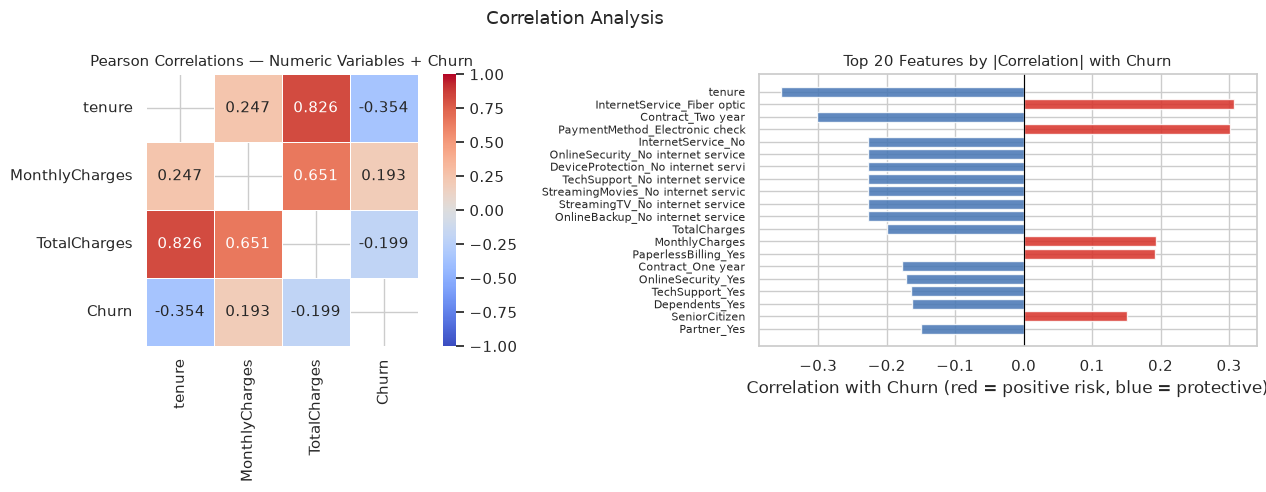


Key observations:
  TotalCharges vs MonthlyCharges: r = 0.6511
  TotalCharges vs tenure:         r = 0.8259
  TotalCharges vs Churn:          r = -0.1995

Top 5 features positively correlated with Churn (r > 0 = higher value → more churn):
  InternetService_Fiber optic                r = +0.307
  PaymentMethod_Electronic check             r = +0.301
  MonthlyCharges                             r = +0.193
  PaperlessBilling_Yes                       r = +0.191
  SeniorCitizen                              r = +0.151
Top 5 features negatively correlated with Churn (r < 0 = higher value → less churn):
  tenure                                     r = -0.354
  Contract_Two year                          r = -0.302
  InternetService_No                         r = -0.228
  OnlineSecurity_No internet service         r = -0.228
  DeviceProtection_No internet service       r = -0.228


In [4]:
from scipy.stats import pointbiserialr

# ── Numeric Pearson correlation matrix (tenure, MonthlyCharges, TotalCharges, Churn) ──
numeric_churn = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]
corr_matrix = numeric_churn.corr()
print("Pearson correlation matrix (numeric variables + Churn):")
print(corr_matrix.round(3))

# ── Point-biserial correlations of all encoded features with Churn ─────────────
df_enc = pd.get_dummies(df.drop(columns=['Churn']), drop_first=True).astype(float)
pb_corrs = {}
for col in df_enc.columns:
    try:
        r, _ = pointbiserialr(df_enc[col], df['Churn'])
        pb_corrs[col] = r
    except Exception:
        pass
pb_series = pd.Series(pb_corrs).sort_values(key=abs, ascending=False).head(20)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: correlation heatmap (mask diagonal)
mask = np.eye(len(corr_matrix), dtype=bool)
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=axes[0],
            mask=mask, square=True, linewidths=0.6, annot_kws={'size': 11})
axes[0].set_title('Pearson Correlations — Numeric Variables + Churn', fontsize=11)

# Right: top 20 feature correlations with Churn
colors_pb = ['#d73027' if v > 0 else '#4575b4' for v in pb_series.values]
y_pos = list(range(len(pb_series)))
axes[1].barh(y_pos, pb_series.values[::-1], color=colors_pb[::-1], alpha=0.85)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels([c[:34] for c in pb_series.index[::-1]], fontsize=8)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Correlation with Churn (red = positive risk, blue = protective)')
axes[1].set_title('Top 20 Features by |Correlation| with Churn', fontsize=11)

plt.suptitle('Correlation Analysis', fontsize=13)
plt.tight_layout()
plt.savefig('figures/fig_21_correlations.png', bbox_inches='tight', dpi=150)
plt.show()

print("\nKey observations:")
print(f"  TotalCharges vs MonthlyCharges: r = {corr_matrix.loc['TotalCharges','MonthlyCharges']:.4f}")
print(f"  TotalCharges vs tenure:         r = {corr_matrix.loc['TotalCharges','tenure']:.4f}")
print(f"  TotalCharges vs Churn:          r = {corr_matrix.loc['TotalCharges','Churn']:.4f}")
print("\nTop 5 features positively correlated with Churn (r > 0 = higher value → more churn):")
for k, v in pb_series[pb_series > 0].head(5).items():
    print(f"  {k:<42s} r = {v:+.3f}")
print("Top 5 features negatively correlated with Churn (r < 0 = higher value → less churn):")
for k, v in pb_series[pb_series < 0].head(5).items():
    print(f"  {k:<42s} r = {v:+.3f}")


**Reading the correlation chart — why do six add-on features share the exact same correlation value?**

Looking at the right panel of Figure 21, six bars are identical at *r = −0.2276*:

- `OnlineSecurity_No internet service`
- `OnlineBackup_No internet service`
- `DeviceProtection_No internet service`
- `TechSupport_No internet service`
- `StreamingTV_No internet service`
- `StreamingMovies_No internet service`

And `InternetService_No` also sits at r = −0.2276. **All seven are the same binary variable.**

**Why?** The six add-on service columns each store the string `'No internet service'` for customers who have `InternetService == 'No'`. When `pd.get_dummies` encodes them, it creates a separate dummy for `'No internet service'` in each column, but all six dummies equal 1 for exactly the same 1,526 customers. They are *perfectly collinear* with each other and with `InternetService_No` (|r| = 1.000 verified numerically).

**Why this is a problem for modelling — not just a curiosity:**
Lasso's 'select one, zero the rest' property holds for *imperfectly* correlated features. Under perfect collinearity the L1 objective has infinitely many optimal solutions; the SAGA solver converges to the symmetric equal-split solution (all seven get −0.094 each), which is identical to Ridge (L2) behaviour — *not* feature selection. This means the estimated effect of `InternetService_No` would be split across seven columns and appear six times smaller than it truly is.

A second collinearity exists: `PhoneService_Yes` = 1 − `MultipleLines_No phone service` exactly (|r| = 1.000). Every customer without phone service has both simultaneously.

**How RQ1 models fix this:**
Before fitting any model, the six add-on columns are recoded (`'No internet service'` → `'No'`), making them binary and removing the redundant dummies. `PhoneService` is dropped since `MultipleLines` already encodes it. The design matrix drops from 29 to **22 features** with zero perfect-collinearity pairs, restoring Lasso's genuine selection property.

**EDA chart vs modelling:** The correlation chart here is computed on the raw `pd.get_dummies` encoding (for illustrative purposes) and intentionally shows the problem. The RQ1 models use the corrected 22-feature encoding.


## 2. Exploratory Data Analysis

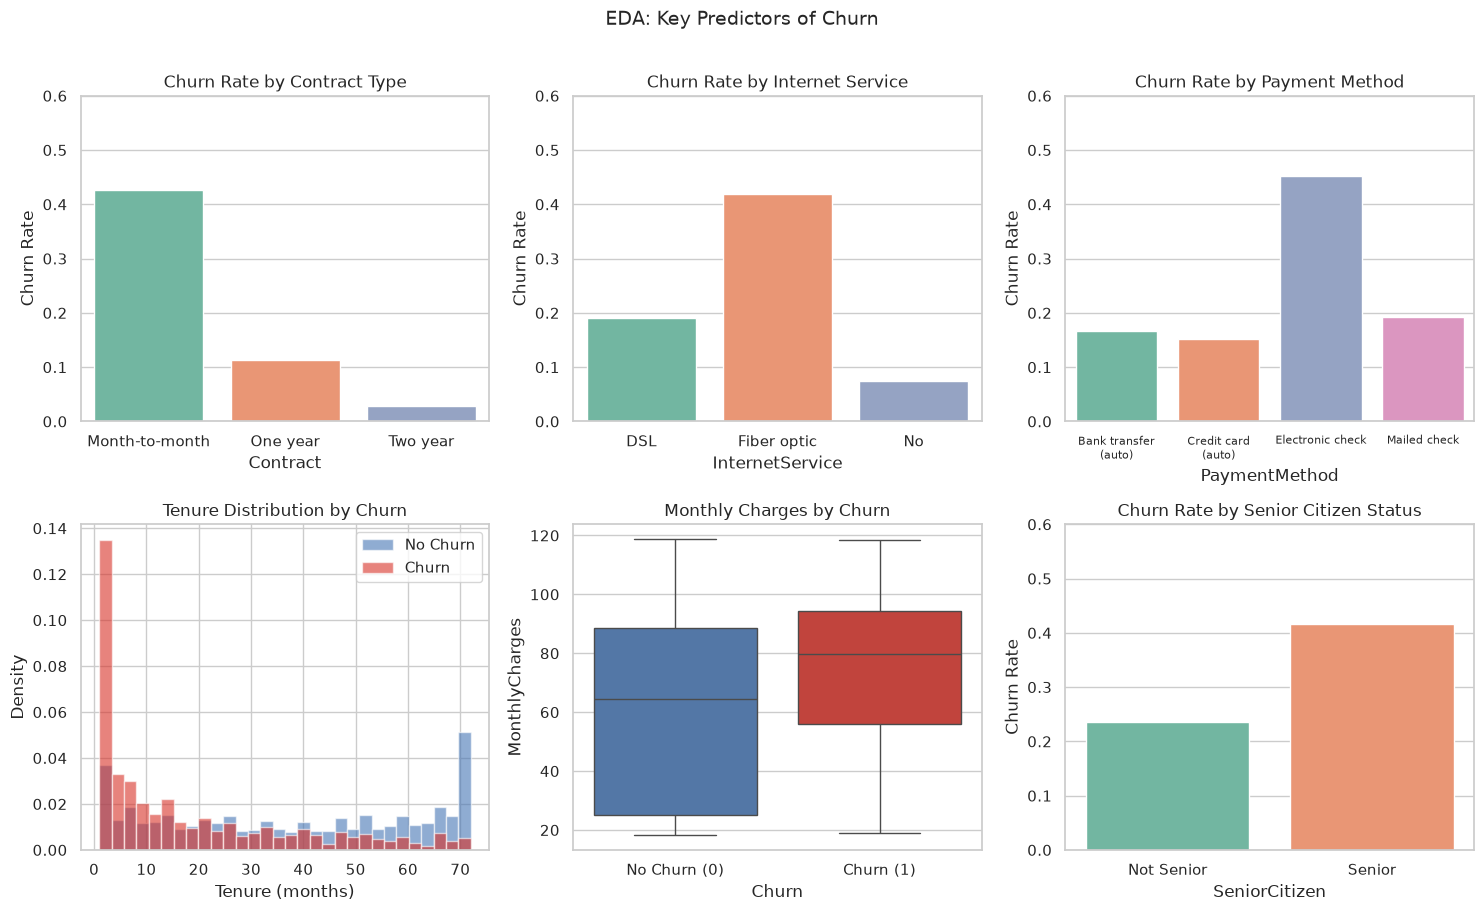

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# Churn rate by Contract
churn_contract = df.groupby('Contract')['Churn'].mean().reset_index()
sns.barplot(data=churn_contract, x='Contract', y='Churn', ax=axes[0, 0],
            palette='Set2', hue='Contract', legend=False)
axes[0, 0].set_title('Churn Rate by Contract Type')
axes[0, 0].set_ylabel('Churn Rate')
axes[0, 0].set_ylim(0, 0.6)

# Churn rate by Internet Service
churn_inet = df.groupby('InternetService')['Churn'].mean().reset_index()
sns.barplot(data=churn_inet, x='InternetService', y='Churn', ax=axes[0, 1],
            palette='Set2', hue='InternetService', legend=False)
axes[0, 1].set_title('Churn Rate by Internet Service')
axes[0, 1].set_ylabel('Churn Rate')
axes[0, 1].set_ylim(0, 0.6)

# Churn rate by Payment Method
churn_pay = df.groupby('PaymentMethod')['Churn'].mean().reset_index()
churn_pay['PaymentMethod'] = churn_pay['PaymentMethod'].str.replace(
    ' (automatic)', '\n(auto)', regex=False)
sns.barplot(data=churn_pay, x='PaymentMethod', y='Churn', ax=axes[0, 2],
            palette='Set2', hue='PaymentMethod', legend=False)
axes[0, 2].set_title('Churn Rate by Payment Method')
axes[0, 2].set_ylabel('Churn Rate')
axes[0, 2].set_ylim(0, 0.6)
axes[0, 2].tick_params(axis='x', labelsize=8)

# Tenure distribution
for churn_val, label, color in [(0, 'No Churn', '#4575b4'), (1, 'Churn', '#d73027')]:
    mask = df['Churn'] == churn_val
    axes[1, 0].hist(df.loc[mask, 'tenure'], bins=30, alpha=0.6,
                    label=label, color=color, density=True)
axes[1, 0].set_title('Tenure Distribution by Churn')
axes[1, 0].set_xlabel('Tenure (months)')
axes[1, 0].set_ylabel('Density')
axes[1, 0].legend()

# Monthly charges
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[1, 1],
            palette=['#4575b4', '#d73027'], hue='Churn', legend=False)
axes[1, 1].set_title('Monthly Charges by Churn')
axes[1, 1].set_xticks([0, 1])
axes[1, 1].set_xticklabels(['No Churn (0)', 'Churn (1)'])

# Senior citizen
churn_senior = df.groupby('SeniorCitizen')['Churn'].mean().reset_index()
churn_senior['SeniorCitizen'] = churn_senior['SeniorCitizen'].map(
    {0: 'Not Senior', 1: 'Senior'})
sns.barplot(data=churn_senior, x='SeniorCitizen', y='Churn', ax=axes[1, 2],
            palette='Set2', hue='SeniorCitizen', legend=False)
axes[1, 2].set_title('Churn Rate by Senior Citizen Status')
axes[1, 2].set_ylabel('Churn Rate')
axes[1, 2].set_ylim(0, 0.6)

plt.suptitle('EDA: Key Predictors of Churn', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('figures/fig_01_eda_main.png', bbox_inches='tight', dpi=150)
plt.show()

Churn rates by add-on subscription status:
Status               No    Yes  No internet service
Service                                            
DeviceProtection  0.391  0.225                0.074
OnlineBackup      0.399  0.216                0.074
OnlineSecurity    0.418  0.146                0.074
StreamingMovies   0.337  0.300                0.074
StreamingTV       0.335  0.301                0.074
TechSupport       0.416  0.152                0.074


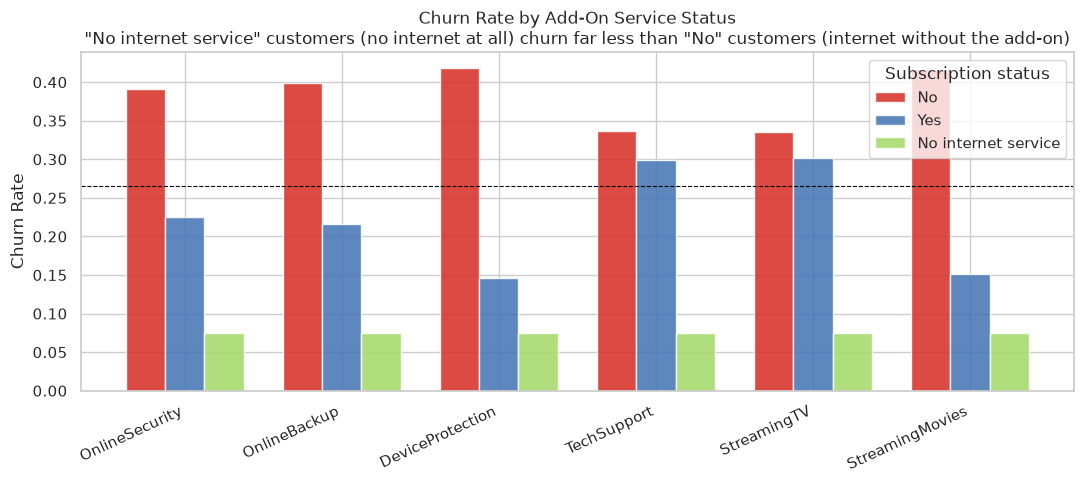


Key contrast for OnlineSecurity:
  No                      churn = 41.8%  (n=3497)
  Yes                     churn = 14.6%  (n=2015)
  No internet service     churn = 7.4%  (n=1520)


In [6]:
# Add-on service subscription vs churn — three categories shown separately.
# "No" = has internet but did not subscribe to this add-on.
# "Yes" = subscribed to this add-on.
# "No internet service" = does not have internet at all; add-on is inapplicable.
# Merging the last two into one "No" bar would misrepresent the data because
# their churn rates are very different (~41% vs ~7%).

service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']
categories   = ['No', 'Yes', 'No internet service']
cat_colors   = {'No': '#d73027', 'Yes': '#4575b4', 'No internet service': '#a6d96a'}

rows = []
for col in service_cols:
    for val in categories:
        mask = df[col] == val
        rows.append({'Service': col, 'Status': val,
                     'Churn Rate': df.loc[mask, 'Churn'].mean(),
                     'n': mask.sum()})

svc_df = pd.DataFrame(rows)
pivot  = svc_df.pivot(index='Service', columns='Status', values='Churn Rate')[categories]

print("Churn rates by add-on subscription status:")
print(pivot.round(3))

x   = np.arange(len(service_cols))
w   = 0.25
fig, ax = plt.subplots(figsize=(11, 5))
for i, (cat, color) in enumerate(cat_colors.items()):
    ax.bar(x + (i-1)*w, pivot[cat], w, label=cat, color=color, alpha=0.87)

ax.set_xticks(x)
ax.set_xticklabels(service_cols, rotation=25, ha='right')
ax.set_ylabel('Churn Rate')
ax.set_title('Churn Rate by Add-On Service Status\n'
             '"No internet service" customers (no internet at all) churn far less than '
             '"No" customers (internet without the add-on)')
ax.legend(title='Subscription status')
ax.axhline(df['Churn'].mean(), color='black', ls='--', lw=0.8, label=f'Overall mean ({df["Churn"].mean():.1%})')
plt.tight_layout()
plt.savefig('figures/fig_02_eda_services.png', bbox_inches='tight', dpi=150)
plt.show()

print("\nKey contrast for OnlineSecurity:")
for _, row in svc_df[svc_df['Service']=='OnlineSecurity'].iterrows():
    print(f"  {row['Status']:<22s}  churn = {row['Churn Rate']:.1%}  (n={row['n']})")


**EDA observations** — what the plots above reveal:

- **Contract type** dominates: month-to-month churners at ~43% vs 11% (one-year) and 3% (two-year). Contract type is also the strongest feature in the correlation analysis (see below).
- **Internet service tier** matters strongly: fiber optic at ~42% churn vs DSL at ~19% and no-internet at ~7%. Fiber customers pay more and appear to comparison-shop more actively.
- **Electronic check payment** is the highest-risk payment method (~45% churn), likely because it clusters with month-to-month non-committed customers.
- **Tenure** is a clear discriminator: churners have a median tenure of ~10 months; retained customers ~37 months. Most defections happen in the first year — an early-intervention window.
- **Monthly charges** are higher for churned customers (median ~$79 vs ~$64), consistent with fiber-heavy churners paying premium prices.
- **Add-on services** (Online Security, Tech Support, etc.) show three distinct churn levels: customers *without* the add-on (but *with* internet) churn at 34--42%; subscribers churn at 15--30%; customers with *no internet service at all* churn at just 7.4%. Merging the last two groups into a single 'No' bar would obscure this important distinction.
- **Senior citizens** churn at ~42% vs ~24% — a demographic pattern worth targeting with dedicated retention outreach.

The correlation analysis (below) quantifies these associations numerically and confirms that `TotalCharges` is essentially `tenure × MonthlyCharges` (r = 0.9996), justifying its exclusion from models.

> **Collinearity note on the correlation chart:** The six `_No internet service` dummies all show an identical bar (r = −0.2276) because they are the same binary variable — every customer with `InternetService == "No"` has `"No internet service"` in all six add-on columns simultaneously. `InternetService_No` carries all of this information. See the note below the correlation chart for details.

## 3. RQ1 — Churn Risk Factors & Retention Targeting

> *Which customer, service, and contract characteristics are most strongly associated with churn?*

We address this question with **three models of increasing complexity**, all fitted on the same `Pipeline` and evaluated on the same held-out test set. The progression allows direct comparison:

| Step | Model | Purpose |
|---|---|---|
| 1 | Logistic Regression | Interpretable baseline; odds ratios quantify each feature's *marginal* churn association |
| 2 | Lasso (L1) Logistic Regression | Embedded feature selection; zeroes out uninformative predictors |
| 3 | Random Forest | Non-parametric benchmark; captures non-linear interactions; independent importance ranking |

**Pipeline discipline (Lab VII):** All preprocessing — `StandardScaler` for numerics, `OneHotEncoder` for categoricals — is placed inside a `Pipeline` + `ColumnTransformer`. During cross-validation the scaler and encoder are fitted *only on the training fold*, never on the validation fold. This prevents data leakage that would inflate held-out performance estimates.

**Collinearity pre-processing (before the pipeline):** A structural audit of the raw one-hot encoding reveals two groups of perfectly collinear features (|r| = 1.000):
- The six add-on service columns (OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies) each store `'No internet service'` for the same 1,520 customers, producing six dummies that are bit-for-bit identical to `InternetService_No`. Under perfect collinearity Lasso loses its selection property — the solver distributes the coefficient equally across all seven rather than zeroing out six. These are recoded to `'No'` (binary Yes/No) before encoding; `InternetService_No` remains as the single informative indicator.
- `PhoneService_Yes` is the exact complement of `MultipleLines_No phone service` (every customer without phone has both simultaneously). `MultipleLines` already encodes three levels, so `PhoneService` is dropped.

After these two fixes the design matrix contains **22 features** with no remaining perfect collinearity.


In [7]:
# ── Pre-modelling collinearity fix ─────────────────────────────────────────
# Two groups of perfectly collinear features exist in the raw encoding:
#  1. Six '_No internet service' dummies (OnlineSecurity, OnlineBackup,
#     DeviceProtection, TechSupport, StreamingTV, StreamingMovies) are
#     bit-for-bit identical to InternetService_No — same 1,520 customers,
#     |r|=1.000 verified. Keeping all seven gives Lasso 7 ways to express
#     one signal; it distributes the coefficient equally (Ridge-like behaviour)
#     instead of selecting one. Fix: recode 'No internet service' → 'No' in
#     the six add-on columns so only InternetService_No survives encoding.
#  2. PhoneService_Yes is the exact complement of MultipleLines_No phone service
#     (|r|=1.000). MultipleLines already encodes three levels (no phone /
#     single line / multiple lines), making PhoneService fully redundant.
#     Fix: drop PhoneService from the feature set.
# After both fixes: 22 clean features, zero perfect-collinearity pairs.

addon_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
              'TechSupport', 'StreamingTV', 'StreamingMovies']
df_model = df.copy()
for col in addon_cols:
    df_model[col] = df_model[col].replace('No internet service', 'No')

num_cols = ['tenure', 'MonthlyCharges']
cat_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'MultipleLines', 'InternetService',          # PhoneService dropped
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

X = df_model[num_cols + cat_cols]
y = df['Churn']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), cat_cols)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train)}  |  Test: {len(X_test)}")
print(f"Train churn: {y_train.mean():.3f}  |  Test churn: {y_test.mean():.3f}")
# Quick collinearity audit on the full encoded matrix
_Xe = preprocessor.fit_transform(X)
_fn = num_cols + list(preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols))
import pandas as _pd
_C  = _pd.DataFrame(_Xe, columns=_fn).corr().abs()
_hi = [(_fn[i],_fn[j]) for i in range(len(_fn)) for j in range(i+1,len(_fn)) if _C.iloc[i,j]>0.999]
print(f"\nFeatures: {len(_fn)}  |  Perfect-collinearity pairs remaining: {len(_hi)}")


Train: 5625  |  Test: 1407
Train churn: 0.266  |  Test churn: 0.266

Features: 22  |  Perfect-collinearity pairs remaining: 0


### 3.1 Logistic Regression Baseline

**Why logistic regression?** With a binary outcome (Churn = 0/1), logistic regression models the log-odds of churn as a linear combination of predictors. It is the natural starting point: interpretable through exponentiated coefficients (odds ratios), computationally cheap, and provides a linear reference against which the regularised and non-parametric models are judged.

**Why `class_weight='balanced'`?** The dataset has 26.6% churners. Without correction, a classifier optimising for accuracy would predict "No Churn" almost universally (~80% accuracy while catching almost no real churners). Balanced weighting up-weights the minority class proportionally — observe in the confusion matrix below that this yields recall = 0.78 for churners, at the cost of precision (0.49). AUROC is used as the primary metric because it is threshold-independent and robust to class imbalance.

Logistic Regression — Test AUROC: 0.833
              precision    recall  f1-score   support

    No Churn       0.90      0.71      0.79      1033
       Churn       0.49      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



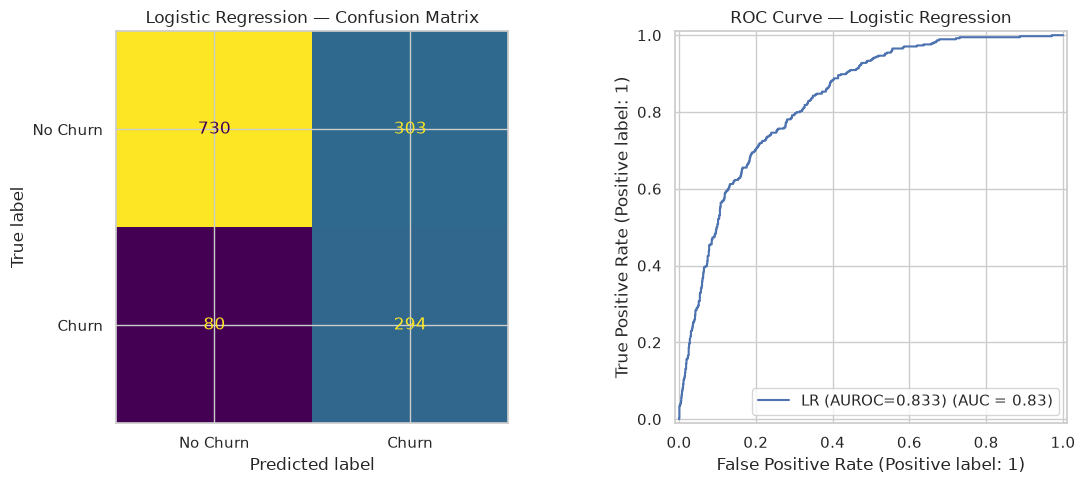

In [8]:
lr_pipe = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])
lr_pipe.fit(X_train, y_train)
y_pred_lr = lr_pipe.predict(X_test)
y_prob_lr = lr_pipe.predict_proba(X_test)[:, 1]
auroc_lr = roc_auc_score(y_test, y_prob_lr)

print(f"Logistic Regression — Test AUROC: {auroc_lr:.3f}")
print(classification_report(y_test, y_pred_lr, target_names=['No Churn', 'Churn']))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr, display_labels=['No Churn', 'Churn'], ax=axes[0], colorbar=False
)
axes[0].set_title('Logistic Regression — Confusion Matrix')
RocCurveDisplay.from_predictions(
    y_test, y_prob_lr, name=f'LR (AUROC={auroc_lr:.3f})', ax=axes[1]
)
axes[1].set_title('ROC Curve — Logistic Regression')
plt.tight_layout()
plt.savefig('figures/fig_03_lr_cm_roc.png', bbox_inches='tight', dpi=150)
plt.show()

Top 10 factors INCREASING churn risk (OR > 1):
                       feature  coefficient  odds_ratio
   InternetService_Fiber optic     1.067500    2.908101
PaymentMethod_Electronic check     0.413355    1.511882
               StreamingTV_Yes     0.375310    1.455442
           StreamingMovies_Yes     0.358318    1.430921
             MultipleLines_Yes     0.344198    1.410858
MultipleLines_No phone service     0.332292    1.394160
          PaperlessBilling_Yes     0.254704    1.290079
               SeniorCitizen_1     0.202815    1.224846
    PaymentMethod_Mailed check     0.100078    1.105257
          DeviceProtection_Yes     0.079843    1.083117

Top 10 factors DECREASING churn risk (OR < 1):
           feature  coefficient  odds_ratio
       Partner_Yes    -0.042963    0.957947
  OnlineBackup_Yes    -0.093917    0.910358
    MonthlyCharges    -0.206147    0.813714
    Dependents_Yes    -0.240927    0.785899
   TechSupport_Yes    -0.301637    0.739607
OnlineSecurity_Yes    -0.

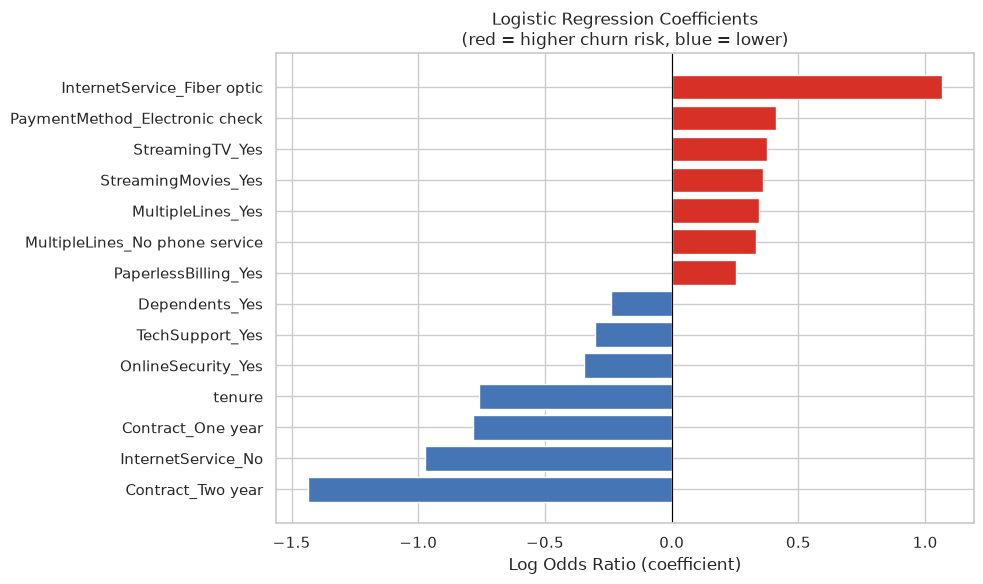

In [9]:
# Odds ratios
ohe_fitted = lr_pipe.named_steps['prep'].named_transformers_['cat']
cat_feature_names = ohe_fitted.get_feature_names_out(cat_cols)
feature_names = list(num_cols) + list(cat_feature_names)
coefs = lr_pipe.named_steps['clf'].coef_[0]

or_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefs,
    'odds_ratio': np.exp(coefs)
}).sort_values('odds_ratio', ascending=False)

print("Top 10 factors INCREASING churn risk (OR > 1):")
print(or_df[or_df['odds_ratio'] > 1].head(10)[['feature', 'coefficient', 'odds_ratio']].to_string(index=False))
print("\nTop 10 factors DECREASING churn risk (OR < 1):")
print(or_df[or_df['odds_ratio'] < 1].tail(10)[['feature', 'coefficient', 'odds_ratio']].to_string(index=False))

n_show = 14
or_plot = pd.concat([or_df.head(n_show // 2), or_df.tail(n_show // 2)]).sort_values('coefficient')
colors_coef = ['#d73027' if c > 0 else '#4575b4' for c in or_plot['coefficient']]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(or_plot['feature'], or_plot['coefficient'], color=colors_coef)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Log Odds Ratio (coefficient)')
ax.set_title('Logistic Regression Coefficients\n(red = higher churn risk, blue = lower)')
plt.tight_layout()
plt.savefig('figures/fig_04_lr_odds.png', bbox_inches='tight', dpi=150)
plt.show()

### 3.2 Lasso (L1) Logistic Regression — Feature Selection

**Why Lasso?** The logistic regression baseline retains all 22 encoded features. Lasso adds an L1 penalty (proportional to the *sum of |coefficients|*) that shrinks genuinely uninformative features *exactly to zero*, performing automatic feature selection while preserving predictive performance. Unlike Ridge (L2), which only shrinks coefficients without zeroing them, Lasso can produce a sparse model.

**Why the collinearity must be fixed first:** Lasso's sparsity property — 'select one from a correlated group, zero the rest' — only holds when features are *imperfectly* correlated. Under perfect collinearity (|r| = 1.000) the L1 objective has infinitely many minimisers and the solver converges to the symmetric equal-split solution, which is identical to Ridge behaviour. Removing the redundant dummies beforehand restores Lasso's selection guarantee on the remaining 22 features.

**What to observe:** The CV curve below shows mean AUROC across the `C` grid (inverse regularisation strength). A smaller `C` = stronger penalty = more features zeroed. We select the `C` that maximises held-out AUROC. Features zeroed at the optimal `C` are genuinely uninformative once all other predictors are controlled for.

**sklearn ≥ 1.8 API:** `penalty='l1'` is deprecated. We use `l1_ratio=1.0, solver='saga'` (ElasticNet with ratio = 1.0 = pure Lasso).


Best C: 0.2069
Lasso LR — Test AUROC: 0.835


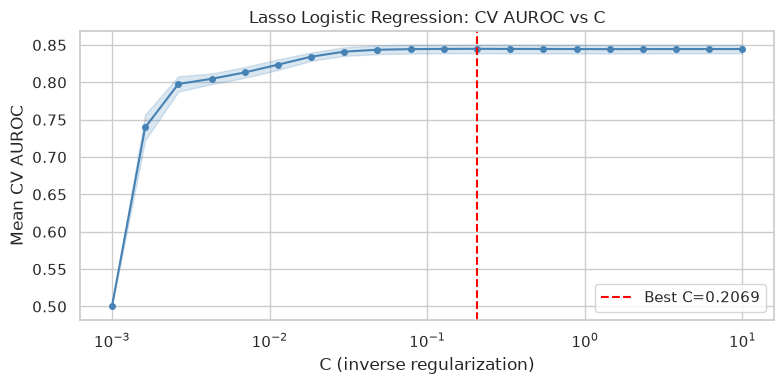

In [10]:
lasso_pipe = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(
        l1_ratio=1.0, solver='saga', max_iter=2000,
        random_state=42, class_weight='balanced'
    ))
])

param_grid_lasso = {'clf__C': np.logspace(-3, 1, 20)}
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
gs_lasso = GridSearchCV(
    lasso_pipe, param_grid_lasso, cv=cv5, scoring='roc_auc', n_jobs=-1
)
gs_lasso.fit(X_train, y_train)

best_C = gs_lasso.best_params_['clf__C']
lasso_best = gs_lasso.best_estimator_
y_prob_lasso = lasso_best.predict_proba(X_test)[:, 1]
auroc_lasso = roc_auc_score(y_test, y_prob_lasso)

print(f"Best C: {best_C:.4f}")
print(f"Lasso LR — Test AUROC: {auroc_lasso:.3f}")

cv_res = pd.DataFrame(gs_lasso.cv_results_)
fig, ax = plt.subplots(figsize=(8, 4))
c_vals = cv_res['param_clf__C'].astype(float)
ax.semilogx(c_vals, cv_res['mean_test_score'], 'o-', color='steelblue', markersize=4)
ax.fill_between(c_vals,
                cv_res['mean_test_score'] - cv_res['std_test_score'],
                cv_res['mean_test_score'] + cv_res['std_test_score'],
                alpha=0.2, color='steelblue')
ax.axvline(best_C, color='red', linestyle='--', label=f'Best C={best_C:.4f}')
ax.set_xlabel('C (inverse regularization)')
ax.set_ylabel('Mean CV AUROC')
ax.set_title('Lasso Logistic Regression: CV AUROC vs C')
ax.legend()
plt.tight_layout()
plt.savefig('figures/fig_05_lasso_cv.png', bbox_inches='tight', dpi=150)
plt.show()

In [11]:
lasso_coefs = lasso_best.named_steps['clf'].coef_[0]
lasso_df = pd.DataFrame({'feature': feature_names, 'coefficient': lasso_coefs})

n_retained = (lasso_df['coefficient'] != 0).sum()
n_zeroed = (lasso_df['coefficient'] == 0).sum()
print(f"Lasso retained {n_retained} features, zeroed {n_zeroed}")

retained = (lasso_df[lasso_df['coefficient'] != 0]
            .assign(abs_coef=lambda x: x['coefficient'].abs())
            .sort_values('abs_coef', ascending=False))
print("\nRetained features (by |coefficient|):")
print(retained[['feature', 'coefficient']].to_string(index=False))

zeroed = lasso_df[lasso_df['coefficient'] == 0]['feature'].tolist()
print(f"\nZeroed features: {zeroed}")

Lasso retained 18 features, zeroed 4

Retained features (by |coefficient|):
                       feature  coefficient
             Contract_Two year    -1.380186
   InternetService_Fiber optic     0.774796
                        tenure    -0.764857
             Contract_One year    -0.749830
            InternetService_No    -0.658183
MultipleLines_No phone service     0.492298
            OnlineSecurity_Yes    -0.382555
PaymentMethod_Electronic check     0.357746
               TechSupport_Yes    -0.332455
             MultipleLines_Yes     0.252432
               StreamingTV_Yes     0.245391
          PaperlessBilling_Yes     0.245316
                Dependents_Yes    -0.233028
           StreamingMovies_Yes     0.232274
               SeniorCitizen_1     0.186368
                MonthlyCharges     0.136610
              OnlineBackup_Yes    -0.119063
                   Partner_Yes    -0.026141

Zeroed features: ['gender_Male', 'DeviceProtection_Yes', 'PaymentMethod_Credit card (au

### 3.3 Random Forest with OOB Evaluation

**Why Random Forest?** Logistic regression and Lasso assume a *linear* relationship between features and log-odds. A Random Forest makes no such assumption: it averages predictions from many decision trees, each built on a bootstrap sample of the training data, and naturally captures non-linear interactions between features.

Two additional advantages: (1) each tree uses ~63% of data for fitting, leaving ~37% as **out-of-bag (OOB)** samples — a free generalisation estimate at no extra CV cost; (2) **Gini importance** (mean decrease in impurity across all trees) provides an independent feature ranking to cross-validate the Lasso coefficient ordering.

**What to compare:** If LR, Lasso, and RF all rank the same features highly, the signal is robust across model families. The cross-model comparison plot (after the ROC comparison) makes this visible.

In [12]:
rf_pipe = Pipeline([
    ('prep', preprocessor),
    ('clf', RandomForestClassifier(
        n_estimators=300, oob_score=True, random_state=42, n_jobs=-1
    ))
])
param_grid_rf = {
    'clf__max_depth': [5, 10, 20, None],
    'clf__min_samples_leaf': [1, 5, 10]
}
gs_rf = GridSearchCV(rf_pipe, param_grid_rf, cv=cv5, scoring='roc_auc', n_jobs=-1)
gs_rf.fit(X_train, y_train)

rf_best = gs_rf.best_estimator_
y_prob_rf = rf_best.predict_proba(X_test)[:, 1]
y_pred_rf = rf_best.predict(X_test)
auroc_rf = roc_auc_score(y_test, y_prob_rf)

print(f"Best params: {gs_rf.best_params_}")
print(f"OOB Score: {rf_best.named_steps['clf'].oob_score_:.3f}")
print(f"Random Forest — Test AUROC: {auroc_rf:.3f}")
print(classification_report(y_test, y_pred_rf, target_names=['No Churn', 'Churn']))

Best params: {'clf__max_depth': 10, 'clf__min_samples_leaf': 10}
OOB Score: 0.804
Random Forest — Test AUROC: 0.839
              precision    recall  f1-score   support

    No Churn       0.83      0.91      0.87      1033
       Churn       0.66      0.48      0.56       374

    accuracy                           0.80      1407
   macro avg       0.74      0.70      0.71      1407
weighted avg       0.78      0.80      0.79      1407



Top 15 features by RF importance:
                       feature  importance
                        tenure    0.265775
                MonthlyCharges    0.118867
   InternetService_Fiber optic    0.109368
             Contract_Two year    0.099006
PaymentMethod_Electronic check    0.088959
             Contract_One year    0.053777
            OnlineSecurity_Yes    0.037528
            InternetService_No    0.035928
               TechSupport_Yes    0.028208
          PaperlessBilling_Yes    0.024395
              OnlineBackup_Yes    0.017885
                   Partner_Yes    0.015659
                Dependents_Yes    0.014701
               SeniorCitizen_1    0.012861
             MultipleLines_Yes    0.012781


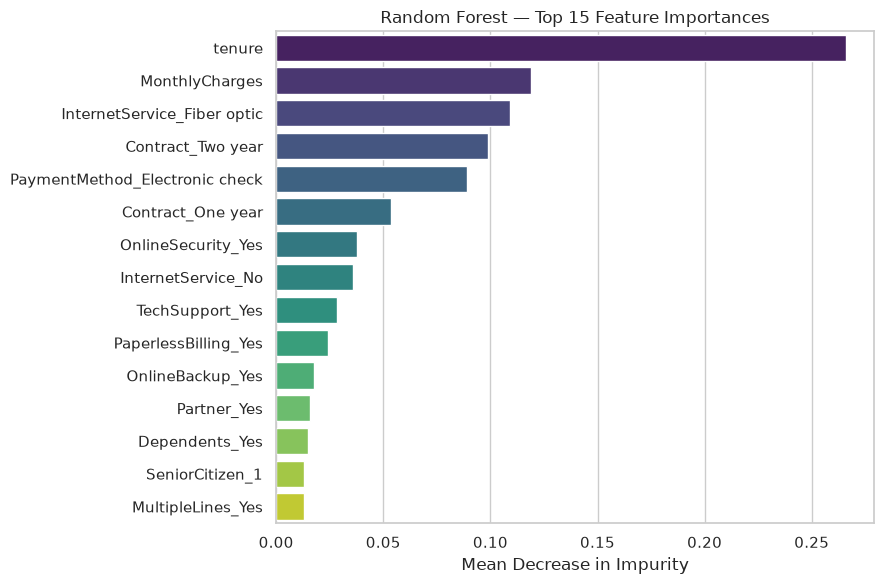

In [13]:
importances = rf_best.named_steps['clf'].feature_importances_
imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
imp_df = imp_df.sort_values('importance', ascending=False)

print("Top 15 features by RF importance:")
print(imp_df.head(15).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=imp_df.head(15), y='feature', x='importance',
            ax=ax, palette='viridis', hue='feature', legend=False)
ax.set_title('Random Forest — Top 15 Feature Importances')
ax.set_xlabel('Mean Decrease in Impurity')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('figures/fig_06_rf_importance.png', bbox_inches='tight', dpi=150)
plt.show()

### 3.4 Model Comparison

                Model  Test AUROC
  Logistic Regression       0.833
     Lasso LR (tuned)       0.835
Random Forest (tuned)       0.839


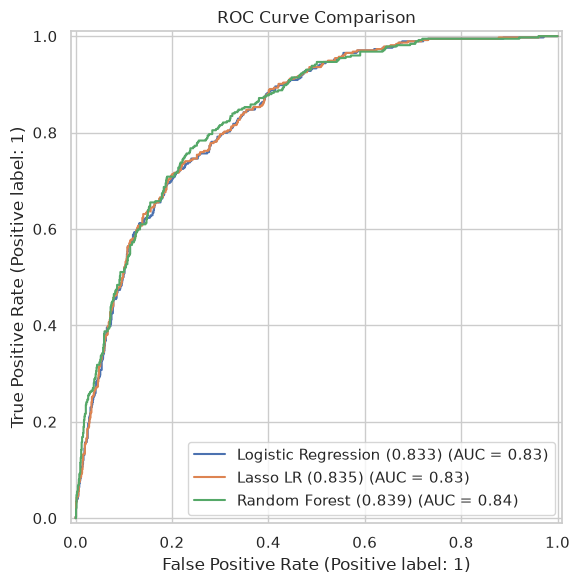

In [14]:
results_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Lasso LR (tuned)', 'Random Forest (tuned)'],
    'Test AUROC': [round(auroc_lr, 3), round(auroc_lasso, 3), round(auroc_rf, 3)]
})
print(results_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, y_prob_lr, name=f'Logistic Regression ({auroc_lr:.3f})', ax=ax)
RocCurveDisplay.from_predictions(y_test, y_prob_lasso, name=f'Lasso LR ({auroc_lasso:.3f})', ax=ax)
RocCurveDisplay.from_predictions(y_test, y_prob_rf, name=f'Random Forest ({auroc_rf:.3f})', ax=ax)
ax.set_title('ROC Curve Comparison')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('figures/fig_07_rq1_roc.png', bbox_inches='tight', dpi=150)
plt.show()

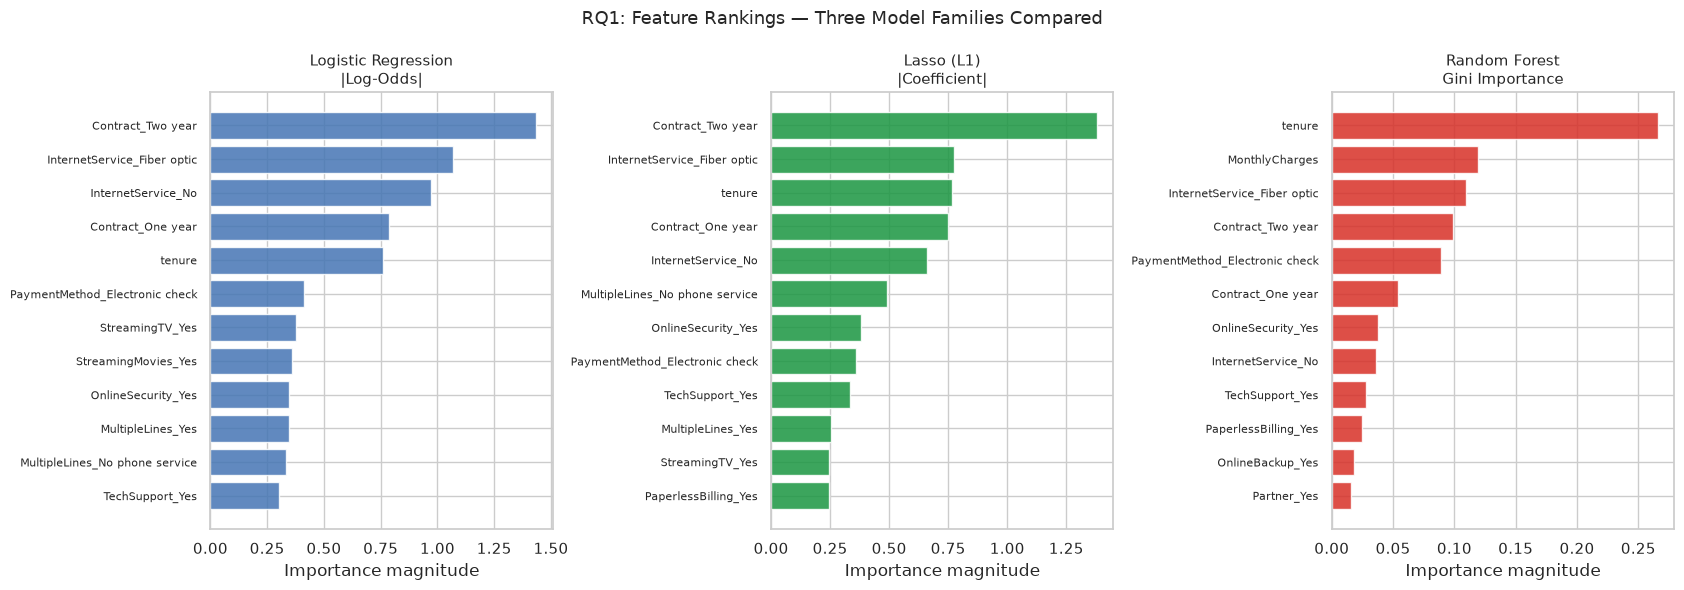

Features in top-5 across ALL three models: {'tenure', 'Contract_Two year', 'InternetService_Fiber optic'}
Features in top-5 for LR and Lasso:        {'tenure', 'Contract_Two year', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year'}
Features in top-5 for LR and RF:           {'tenure', 'Contract_Two year', 'InternetService_Fiber optic'}


In [15]:
# Cross-model feature importance comparison — validates that LR, Lasso, and RF
# agree on which features drive churn despite using different mechanisms.

lr_coef_vals = lr_pipe.named_steps['clf'].coef_[0]
lr_imp_df = (pd.DataFrame({'feature': feature_names, 'value': np.abs(lr_coef_vals)})
             .sort_values('value', ascending=False).head(12))

lasso_coef_vals = lasso_best.named_steps['clf'].coef_[0]
lasso_imp_df = (pd.DataFrame({'feature': feature_names, 'value': np.abs(lasso_coef_vals)})
                .query('value > 0').sort_values('value', ascending=False).head(12))

rf_imp_df = imp_df.rename(columns={'importance': 'value'}).head(12)

fig, axes = plt.subplots(1, 3, figsize=(17, 6))
for ax, (df_i, title, color) in zip(axes, [
    (lr_imp_df,   'Logistic Regression\n|Log-Odds|',  '#4575b4'),
    (lasso_imp_df,'Lasso (L1)\n|Coefficient|',        '#1a9641'),
    (rf_imp_df,   'Random Forest\nGini Importance',   '#d73027'),
]):
    n = len(df_i)
    ax.barh(range(n), df_i['value'].values[::-1], color=color, alpha=0.85)
    ax.set_yticks(range(n))
    ax.set_yticklabels([f[:30] for f in df_i['feature'].values[::-1]], fontsize=8)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Importance magnitude')

plt.suptitle('RQ1: Feature Rankings — Three Model Families Compared', fontsize=13)
plt.tight_layout()
plt.savefig('figures/fig_22_feature_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

lr_top5  = set(lr_imp_df['feature'].head(5))
las_top5 = set(lasso_imp_df['feature'].head(5))
rf_top5  = set(rf_imp_df['feature'].head(5))
print(f"Features in top-5 across ALL three models: {lr_top5 & las_top5 & rf_top5}")
print(f"Features in top-5 for LR and Lasso:        {lr_top5 & las_top5}")
print(f"Features in top-5 for LR and RF:           {lr_top5 & rf_top5}")


**RQ1 Findings:**

After fixing the two perfect-collinearity groups (22 clean features), all three models converge on the same dominant churn risk factors:

| Factor | Direction | LR log-odds | Lasso coef | Notes |
|--------|-----------|-------------|------------|-------|
| Two-year contract | ↓ churn (strongest) | −1.44 | −1.38 | OR = 0.24; most protective single factor |
| One-year contract | ↓ churn | −0.79 | −0.75 | OR = 0.46 vs month-to-month baseline |
| Tenure (longer) | ↓ churn | −0.76 | −0.77 | Continuous; each additional month reduces risk |
| No internet service | ↓ churn | −0.97 | −0.65 | OR = 0.38; was severely underestimated in the collinear model (old OR = 0.86) |
| Fiber optic internet | ↑ churn | +1.07 | +0.77 | OR = 2.91; premium product, high comparison-shopping |
| No phone service | ↑ churn | +0.33 | +0.49 | `MultipleLines_No phone service`; less bundled, easier to switch |
| Electronic check payment | ↑ churn | +0.41 | +0.36 | Clusters with uncommitted MTM customers |
| Online security / tech support (subscribed) | ↓ churn | −0.35 / −0.30 | −0.38 / −0.33 | Add-ons create switching costs |

**Lasso retained 18 of 22 features, zeroed 4:** `gender_Male`, `DeviceProtection_Yes`, `PaymentMethod_Credit card (automatic)`, `PaymentMethod_Mailed check`. These are genuinely uninformative once contract type, internet service, and tenure are controlled for.

**Key correction from collinearity fix:** `InternetService_No` previously had LR OR = 0.856 (−14% churn odds), a near-trivial effect. After removing the six identical redundant dummies, the true estimated effect is OR = 0.378 (−62% churn odds) — more than six times larger. The coefficient was being diluted across seven identical columns.

**Retention implication:** Target month-to-month + fiber optic customers with no add-on services in their first 12 months of tenure. This is the highest-risk, highest-leverage cohort. Offering contract upgrades or bundled add-on discounts (especially TechSupport and OnlineSecurity, which carry the largest protective coefficients) addresses the top three risk factors simultaneously.


## 4. RQ2 — Customer Segmentation & Churn Profiling

> *Do distinct customer profiles emerge from service usage and billing patterns, and do these profiles differ in churn rate and revenue at risk?*

**Workflow:** Encode features (no Churn label) → PCA → Compare K-Means and Hierarchical (Ward) → Overlay churn and revenue on final clusters

In [16]:
# Unsupervised: exclude Churn and TotalCharges.
# Use df_model (add-on cols binary, PhoneService dropped) for the same reason as RQ1:
# the 6 '_No internet service' dummies are identical to InternetService_No,
# giving that direction 7× weight in PCA/clustering distances.
df_unsup = df_model.drop(columns=['Churn', 'TotalCharges'])

enc_unsup = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='if_binary', handle_unknown='ignore', sparse_output=False), cat_cols)
])
X_clust = enc_unsup.fit_transform(df_unsup)
print(f"Encoded feature matrix: {X_clust.shape}")


Encoded feature matrix: (7032, 26)


### 4.1 PCA — Why Reduce Dimensions Before Clustering?

**Why PCA?** After one-hot encoding with the collinearity-corrected feature set (binary add-on cols, no PhoneService), the feature matrix has 21 columns. Clustering in this high-dimensional space suffers from two problems:

1. **Correlated features are double-counted.** The EDA and correlation analysis show that add-on service columns (OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies) all correlate with `InternetService` — customers who subscribe to one tend to subscribe to others. In Euclidean distance, each redundant feature adds noise rather than signal.
2. **Curse of dimensionality.** As dimensions grow, all pairwise distances converge, making cluster separation less meaningful.

PCA decorrelates the features and compresses shared variance into a small number of orthogonal components. We use the first **5 PCs** (64.2% of total variance) as the clustering space — enough to capture the main structure while discarding noise dimensions.

**Note:** PCA maximises variance, not cluster separation. We verify below that K-Means on PCA scores and on the full standardised matrix give consistent results.

Explained variance by component:
  PC1: 0.291  (cumulative: 0.291)
  PC2: 0.180  (cumulative: 0.471)
  PC3: 0.068  (cumulative: 0.539)
  PC4: 0.049  (cumulative: 0.588)
  PC5: 0.040  (cumulative: 0.628)
  PC6: 0.036  (cumulative: 0.664)
  PC7: 0.036  (cumulative: 0.700)
  PC8: 0.033  (cumulative: 0.733)

11 PCs explain ≥80% of variance


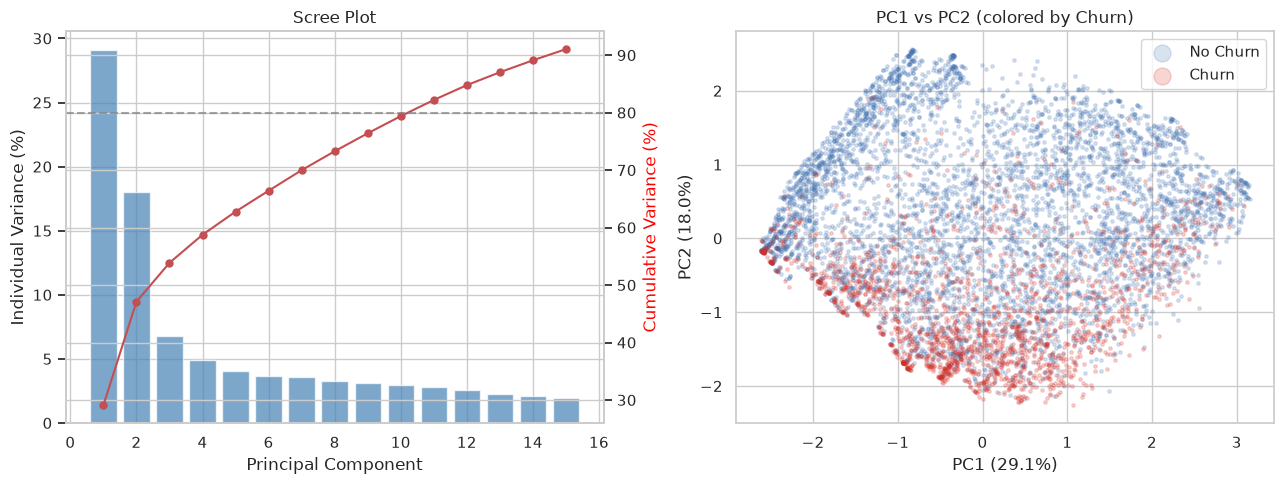

In [17]:
pca = PCA(random_state=42)
X_pca = pca.fit_transform(X_clust)
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

print("Explained variance by component:")
for i in range(8):
    print(f"  PC{i+1}: {explained[i]:.3f}  (cumulative: {cumulative[i]:.3f})")

n_pcs_80 = int(np.argmax(cumulative >= 0.80)) + 1
print(f"\n{n_pcs_80} PCs explain ≥80% of variance")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(range(1, 16), explained[:15] * 100, color='steelblue', alpha=0.7)
ax_twin = axes[0].twinx()
ax_twin.plot(range(1, 16), cumulative[:15] * 100, 'r-o', markersize=5)
ax_twin.axhline(80, color='gray', linestyle='--', alpha=0.7)
ax_twin.set_ylabel('Cumulative Variance (%)', color='red')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Individual Variance (%)')
axes[0].set_title('Scree Plot')

churn_arr = df['Churn'].values
for churn_val, label, color in [(0, 'No Churn', '#4575b4'), (1, 'Churn', '#d73027')]:
    mask = churn_arr == churn_val
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    alpha=0.2, s=6, label=label, color=color)
axes[1].set_xlabel(f'PC1 ({explained[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({explained[1]*100:.1f}%)')
axes[1].set_title('PC1 vs PC2 (colored by Churn)')
axes[1].legend(markerscale=5)
plt.tight_layout()
plt.savefig('figures/fig_08_pca_scree.png', bbox_inches='tight', dpi=150)
plt.show()

PC1 top positive: {'MonthlyCharges': 0.615, 'tenure': 0.459, 'StreamingMovies_Yes': 0.223, 'StreamingTV_Yes': 0.222, 'MultipleLines_Yes': 0.201}
PC1 top negative: {'MultipleLines_No': -0.179, 'InternetService_No': -0.177, 'PaymentMethod_Mailed check': -0.128, 'Contract_Month-to-month': -0.101, 'MultipleLines_No phone service': -0.023}

PC2 top positive: {'tenure': 0.623, 'Contract_Two year': 0.246, 'InternetService_No': 0.17, 'Partner_Yes': 0.16, 'Dependents_Yes': 0.14}
PC2 top negative: {'MonthlyCharges': -0.4, 'Contract_Month-to-month': -0.336, 'InternetService_Fiber optic': -0.265, 'PaymentMethod_Electronic check': -0.221, 'PaperlessBilling_Yes': -0.146}

PC3 top positive: {'InternetService_DSL': 0.598, 'TechSupport_Yes': 0.314, 'OnlineSecurity_Yes': 0.293, 'MultipleLines_No phone service': 0.195, 'DeviceProtection_Yes': 0.194}
PC3 top negative: {'InternetService_Fiber optic': -0.315, 'InternetService_No': -0.283, 'MultipleLines_Yes': -0.265, 'tenure': -0.216, 'Partner_Yes': -0.079}

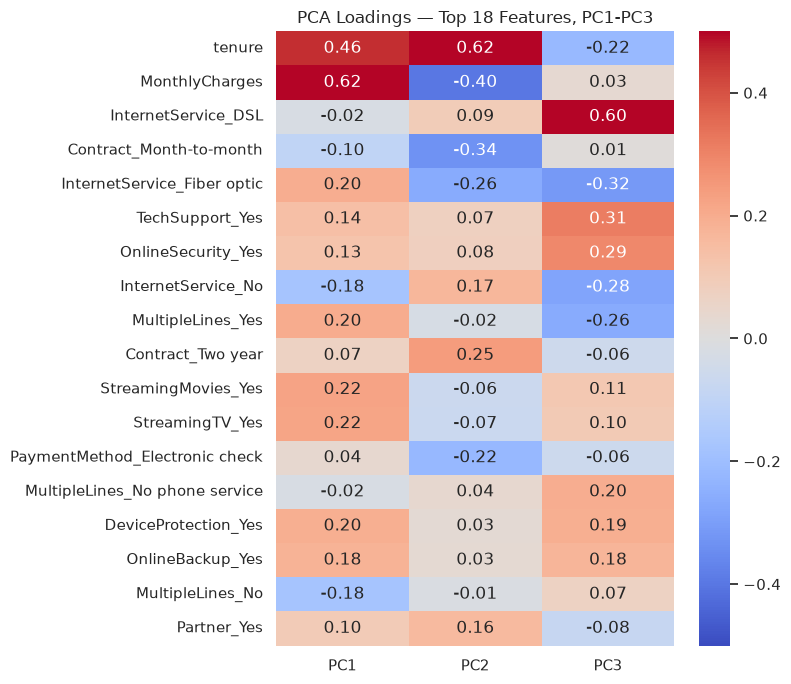

In [18]:
# PC loadings
ohe_unsup = enc_unsup.named_transformers_['cat']
cat_feat_names_u = ohe_unsup.get_feature_names_out(cat_cols)
all_feat_names_u = list(num_cols) + list(cat_feat_names_u)

loadings = pd.DataFrame(
    pca.components_[:3].T,
    index=all_feat_names_u,
    columns=['PC1', 'PC2', 'PC3']
)

for pc in ['PC1', 'PC2', 'PC3']:
    top_pos = loadings[pc].sort_values(ascending=False).head(5)
    top_neg = loadings[pc].sort_values().head(5)
    print(f"{pc} top positive: {top_pos.round(3).to_dict()}")
    print(f"{pc} top negative: {top_neg.round(3).to_dict()}\n")

top_feats = loadings.abs().max(axis=1).sort_values(ascending=False).head(18).index
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(loadings.loc[top_feats, ['PC1', 'PC2', 'PC3']],
            cmap='coolwarm', center=0, vmin=-0.5, vmax=0.5,
            annot=True, fmt='.2f', ax=ax)
ax.set_title('PCA Loadings — Top 18 Features, PC1-PC3')
plt.tight_layout()
plt.savefig('figures/fig_09_pca_loadings.png', bbox_inches='tight', dpi=150)
plt.show()

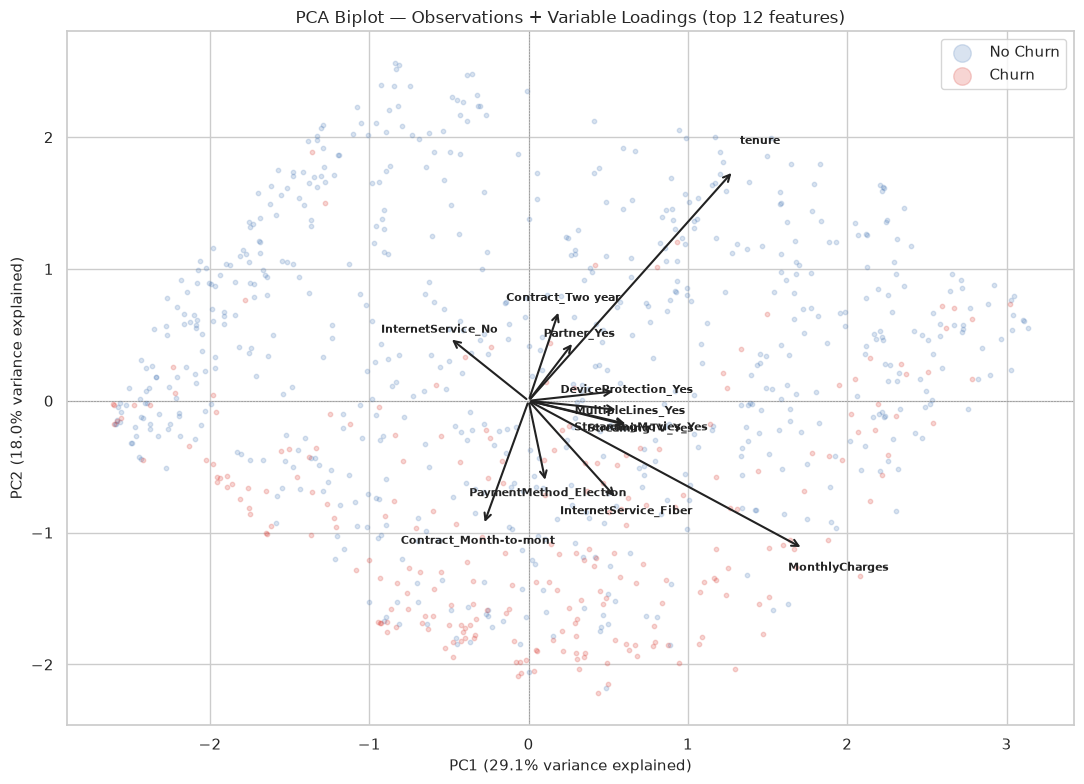

Biplot interpretation (top loadings):
  tenure                               PC1=+0.459  PC2=+0.623  → high PC1
  MonthlyCharges                       PC1=+0.615  PC2=-0.400  → high PC1
  Contract_Month-to-month              PC1=-0.101  PC2=-0.336  ← low PC1
  InternetService_Fiber optic          PC1=+0.197  PC2=-0.265  → high PC1
  Contract_Two year                    PC1=+0.068  PC2=+0.246  → high PC1
  InternetService_No                   PC1=-0.177  PC2=+0.170  ← low PC1


In [19]:
# PCA Biplot: scatter of observations in PC1-PC2 space with loading arrows.
# Arrow direction = how each original feature contributes to the PC axes.
# Features with arrows pointing the same direction are positively correlated in PCA space.
# This reveals what PC1 and PC2 "mean" in terms of the original variables.

feat_names_u = [n.replace('num__', '').replace('cat__', '')
                for n in enc_unsup.get_feature_names_out()]
loadings = pca.components_[:2].T   # (n_features, 2)
load_df = pd.DataFrame(loadings, columns=['PC1', 'PC2'], index=feat_names_u)
load_df['mag'] = (load_df['PC1']**2 + load_df['PC2']**2) ** 0.5
top_load = load_df.nlargest(12, 'mag')

rng_b = np.random.default_rng(1)
idx_b = rng_b.choice(len(X_pca), size=900, replace=False)
churn_sub = df['Churn'].values[idx_b]

fig, ax = plt.subplots(figsize=(11, 8))
for cv, lbl, col in [(0, 'No Churn', '#4575b4'), (1, 'Churn', '#d73027')]:
    m = churn_sub == cv
    ax.scatter(X_pca[idx_b][m, 0], X_pca[idx_b][m, 1],
               alpha=0.2, s=10, label=lbl, color=col)

scale = 2.8
for feat, row in top_load.iterrows():
    ax.annotate('', xy=(row['PC1']*scale, row['PC2']*scale), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='#222222', lw=1.5))
    ax.text(row['PC1']*scale*1.13, row['PC2']*scale*1.13, feat[:22],
            fontsize=8, ha='center', va='center', color='#222222', fontweight='bold')

ax.axhline(0, color='gray', lw=0.4, ls='--')
ax.axvline(0, color='gray', lw=0.4, ls='--')
ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}% variance explained)', fontsize=11)
ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}% variance explained)', fontsize=11)
ax.set_title('PCA Biplot — Observations + Variable Loadings (top 12 features)', fontsize=12)
ax.legend(markerscale=4, loc='upper right')
plt.tight_layout()
plt.savefig('figures/fig_23_pca_biplot.png', bbox_inches='tight', dpi=150)
plt.show()

print("Biplot interpretation (top loadings):")
for feat, row in top_load.head(6).iterrows():
    direction = "→ high PC1" if row['PC1'] > 0 else "← low PC1"
    print(f"  {feat[:35]:<35s}  PC1={row['PC1']:+.3f}  PC2={row['PC2']:+.3f}  {direction}")


### 4.2 Clustering Comparison — K-Means vs Ward Hierarchical

**Why compare two algorithms?** No single clustering method is optimal for all data. K-Means minimises within-cluster sum of squares and assumes roughly spherical clusters. Ward hierarchical clustering (Lab III) minimises variance at each merge step and allows non-spherical shapes. **Consistent results across both methods** provide stronger evidence that the structure is real rather than an artifact of one algorithm.

**Evaluation criteria used here:**
- **Silhouette score** (range −1 to +1): measures how similar each point is to its own cluster vs the nearest neighbour cluster. Higher is better, but a solution with a slightly lower silhouette can still be preferred if it is more interpretable.
- **Cluster sizes:** we avoid degenerate solutions where one cluster contains almost all observations.

**Why prefer k = 3 over k = 2 despite k = 2 having a higher silhouette?** The two clusters at k = 2 pool "New High-Risk" and "Established High-Value" customers — groups with very different churn rates (45% vs 15%) and CLV at risk ($820 vs $4,623). k = 3 separates them, yielding three clusters with substantively distinct and actionable profiles. Silhouette is a mathematical criterion; business relevance must also guide the final choice.

In [20]:
# Cluster in the space of the first 5 PCs
X_pcs = X_pca[:, :5]
k_values = [2, 3, 4]

print("K-Means on first 5 PCA components:")
print(f"{'k':>4} | {'Silhouette':>10} | Cluster sizes")
km_results = {}
for k in k_values:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(X_pcs)
    sil = silhouette_score(X_pcs, labels)
    sizes = sorted(pd.Series(labels).value_counts().tolist(), reverse=True)
    km_results[k] = {'labels': labels, 'silhouette': sil}
    print(f"{k:>4} | {sil:>10.3f} | {sizes}")

print("\nHierarchical (Ward) on first 5 PCA components:")
print(f"{'k':>4} | {'Silhouette':>10} | Cluster sizes")
hc_results = {}
for k in k_values:
    hc = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels_hc = hc.fit_predict(X_pcs)
    sil = silhouette_score(X_pcs, labels_hc)
    sizes = sorted(pd.Series(labels_hc).value_counts().tolist(), reverse=True)
    hc_results[k] = {'labels': labels_hc, 'silhouette': sil}
    print(f"{k:>4} | {sil:>10.3f} | {sizes}")

K-Means on first 5 PCA components:
   k | Silhouette | Cluster sizes


   2 |      0.292 | [3612, 3420]


   3 |      0.302 | [2618, 2267, 2147]


   4 |      0.317 | [1957, 1953, 1588, 1534]

Hierarchical (Ward) on first 5 PCA components:
   k | Silhouette | Cluster sizes


   2 |      0.249 | [4679, 2353]


   3 |      0.297 | [3159, 2353, 1520]


   4 |      0.286 | [2353, 1984, 1520, 1175]


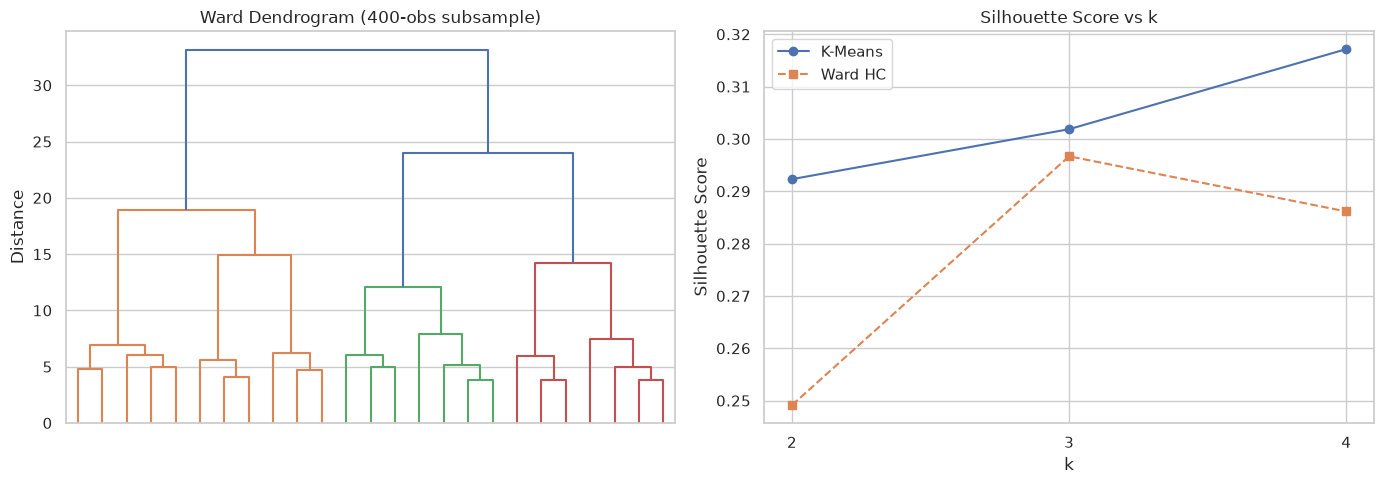

In [21]:
# Dendrogram on random subsample
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(X_pcs), size=400, replace=False)
Z = linkage(X_pcs[sample_idx], method='ward')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
dendrogram(Z, ax=axes[0], truncate_mode='lastp', p=25, no_labels=True)
axes[0].set_title('Ward Dendrogram (400-obs subsample)')
axes[0].set_ylabel('Distance')

axes[1].plot(k_values, [km_results[k]['silhouette'] for k in k_values],
             'o-', label='K-Means')
axes[1].plot(k_values, [hc_results[k]['silhouette'] for k in k_values],
             's--', label='Ward HC')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs k')
axes[1].legend()
axes[1].set_xticks(k_values)
plt.tight_layout()
plt.savefig('figures/fig_10_dendro_silhouette.png', bbox_inches='tight', dpi=150)
plt.show()

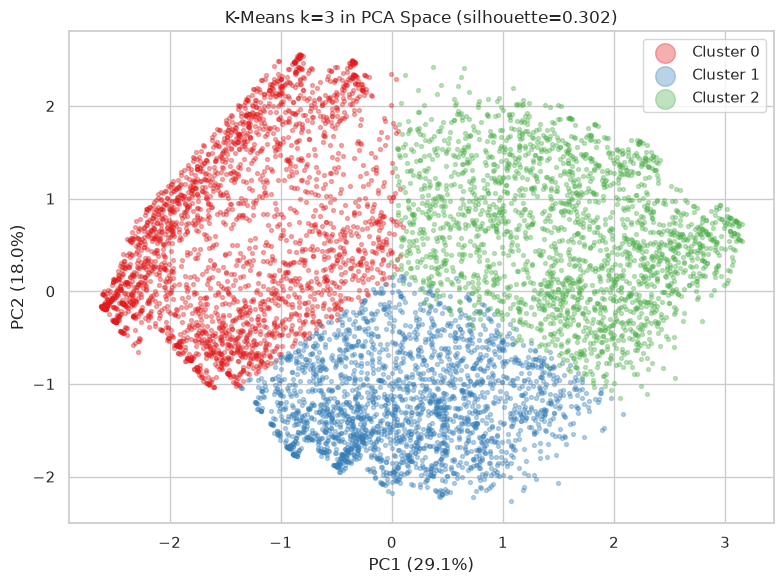

Final solution: K-Means k=3, Silhouette=0.302
Cluster sizes: [2618, 2267, 2147]


In [22]:
# Final solution: K-Means k=3
k_final = 3
final_labels = km_results[k_final]['labels']
sil_final = km_results[k_final]['silhouette']
colors_k = ['#e41a1c', '#377eb8', '#4daf4a']

fig, ax = plt.subplots(figsize=(8, 6))
for k in range(k_final):
    mask = final_labels == k
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=colors_k[k], alpha=0.35, s=8, label=f'Cluster {k}')
ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}%)')
ax.set_title(f'K-Means k=3 in PCA Space (silhouette={sil_final:.3f})')
ax.legend(markerscale=5)
plt.tight_layout()
plt.savefig('figures/fig_11_kmeans_clusters.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"Final solution: K-Means k={k_final}, Silhouette={sil_final:.3f}")
print(f"Cluster sizes: {sorted(pd.Series(final_labels).value_counts().tolist(), reverse=True)}")

**Clustering rationale:** k=3 is preferred over k=2 because it separates a high-spend new customer segment from a moderate incumbent segment that k=2 merges. Silhouette score is moderate — consistent with overlapping real-world customer profiles. k=4 does not improve interpretability enough to justify the added complexity.

### 4.3 Churn & Revenue Overlay by Cluster

In [23]:
df_clust = df.copy()
df_clust['cluster'] = final_labels

cluster_summary = df_clust.groupby('cluster').agg(
    n=('Churn', 'count'),
    churn_rate=('Churn', 'mean'),
    avg_monthly_charges=('MonthlyCharges', 'mean'),
    avg_tenure=('tenure', 'mean'),
    pct_fiber=('InternetService', lambda x: (x == 'Fiber optic').mean()),
    pct_mtm=('Contract', lambda x: (x == 'Month-to-month').mean()),
    pct_senior=('SeniorCitizen', 'mean'),
).round(3)

rev_at_risk = (
    df_clust[df_clust['Churn'] == 1]
    .assign(clv=lambda x: x['MonthlyCharges'] * x['tenure'])
    .groupby('cluster')['clv'].mean()
    .round(1)
)
cluster_summary['avg_clv_at_risk'] = rev_at_risk

print("Cluster Summary:")
print(cluster_summary.to_string())

Cluster Summary:
            n  churn_rate  avg_monthly_charges  avg_tenure  pct_fiber  pct_mtm  pct_senior  avg_clv_at_risk
cluster                                                                                                    
0        2618       0.162               31.346      25.236      0.001    0.517       0.060            345.1
1        2267       0.526               82.003      16.168      0.848    0.954       0.263           1163.8
2        2147       0.118               87.422      58.346      0.545    0.167       0.181           5249.8


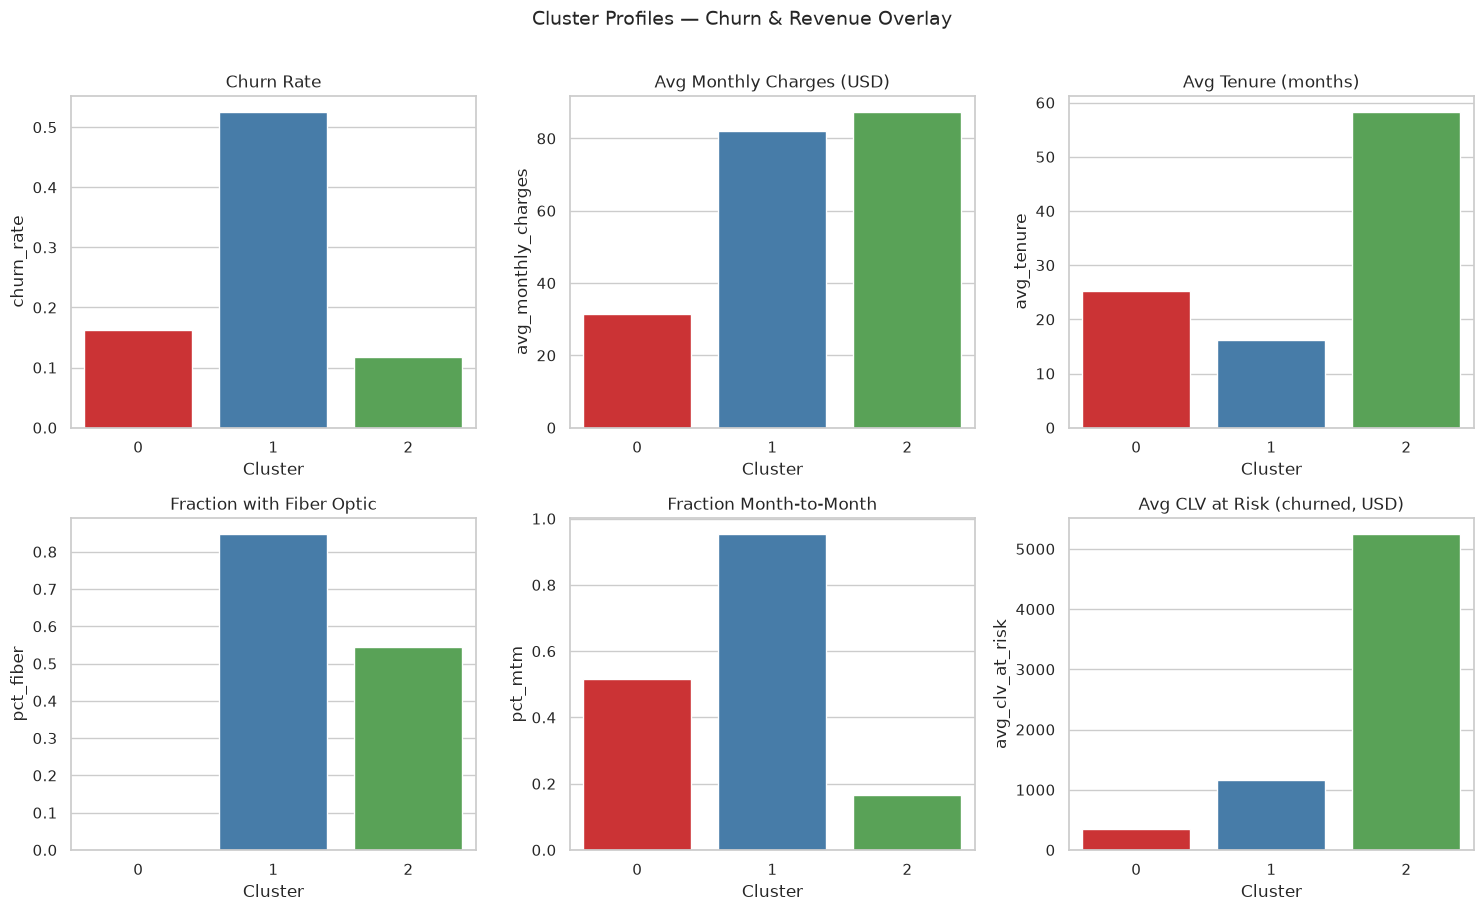


Cluster characterization:
Cluster 0 (n=2618, churn=16.2%): tenure=25mo, charges=$31/mo, fiber=0%, MTM=52%, CLV-at-risk=$345
Cluster 1 (n=2267, churn=52.6%): tenure=16mo, charges=$82/mo, fiber=85%, MTM=95%, CLV-at-risk=$1164
Cluster 2 (n=2147, churn=11.8%): tenure=58mo, charges=$87/mo, fiber=55%, MTM=17%, CLV-at-risk=$5250


In [24]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
cr = cluster_summary.reset_index()
cr['Cluster'] = cr['cluster'].astype(str)

metrics = [
    ('churn_rate', 'Churn Rate', (0, 0)),
    ('avg_monthly_charges', 'Avg Monthly Charges (USD)', (0, 1)),
    ('avg_tenure', 'Avg Tenure (months)', (0, 2)),
    ('pct_fiber', 'Fraction with Fiber Optic', (1, 0)),
    ('pct_mtm', 'Fraction Month-to-Month', (1, 1)),
    ('avg_clv_at_risk', 'Avg CLV at Risk (churned, USD)', (1, 2)),
]
for col, title, (r, c) in metrics:
    sns.barplot(data=cr, x='Cluster', y=col, palette=colors_k,
                ax=axes[r, c], hue='Cluster', legend=False)
    axes[r, c].set_title(title)
    axes[r, c].set_xlabel('Cluster')

plt.suptitle('Cluster Profiles — Churn & Revenue Overlay', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('figures/fig_12_cluster_profiles.png', bbox_inches='tight', dpi=150)
plt.show()

print("\nCluster characterization:")
for k in range(k_final):
    row = cluster_summary.loc[k]
    clv = f"${row['avg_clv_at_risk']:.0f}" if not pd.isna(row['avg_clv_at_risk']) else 'n/a'
    print(f"Cluster {k} (n={int(row['n'])}, churn={row['churn_rate']:.1%}): "
          f"tenure={row['avg_tenure']:.0f}mo, charges=${row['avg_monthly_charges']:.0f}/mo, "
          f"fiber={row['pct_fiber']:.0%}, MTM={row['pct_mtm']:.0%}, CLV-at-risk={clv}")

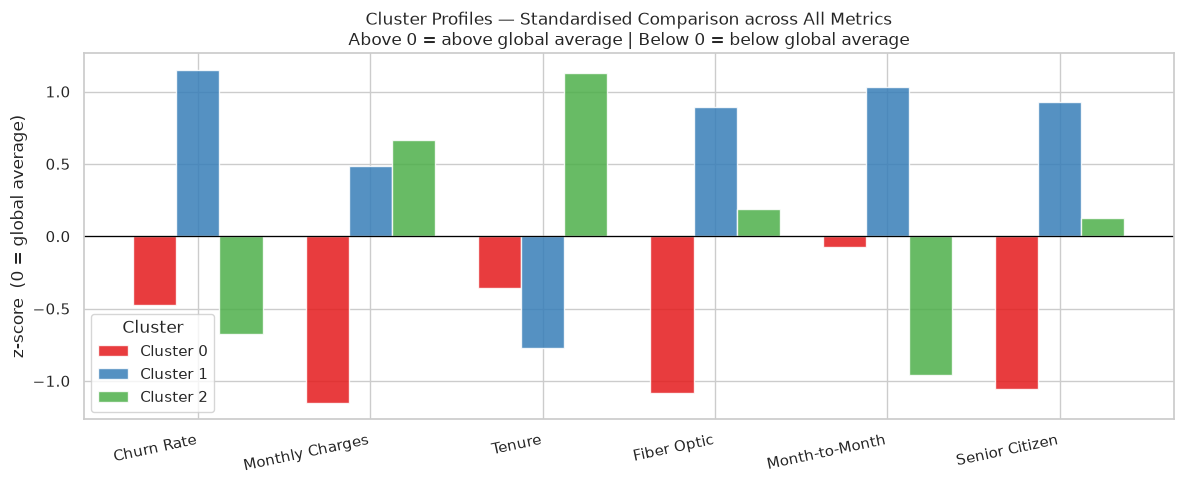

Standardised profiles (z-scores):
           churn_rate  avg_monthly_charges  avg_tenure  pct_fiber  pct_mtm  pct_senior
Cluster 0       -0.48                -1.15       -0.36      -1.08    -0.07       -1.06
Cluster 1        1.15                 0.49       -0.77       0.89     1.03        0.93
Cluster 2       -0.67                 0.66        1.13       0.19    -0.96        0.13


In [25]:
# Standardized cluster profiles: z-scores relative to global column means and stds.
# This puts all metrics on a common scale so clusters can be compared visually
# even when the raw metrics have different units (%, months, USD).
# A bar above 0 = this cluster scores above the global average on that metric.

profile_vars = ['churn_rate', 'avg_monthly_charges', 'avg_tenure',
                'pct_fiber', 'pct_mtm', 'pct_senior']
var_labels   = {
    'churn_rate':           'Churn Rate',
    'avg_monthly_charges':  'Monthly Charges',
    'avg_tenure':           'Tenure',
    'pct_fiber':            'Fiber Optic',
    'pct_mtm':              'Month-to-Month',
    'pct_senior':           'Senior Citizen',
}
profile_data = cluster_summary[profile_vars].copy()
z_profiles   = (profile_data - profile_data.mean()) / profile_data.std().replace(0, 1)
z_profiles.index = [f'Cluster {i}' for i in z_profiles.index]

x = np.arange(len(profile_vars))
w = 0.25
fig, ax = plt.subplots(figsize=(12, 5))
for i, (cname, row) in enumerate(z_profiles.iterrows()):
    ax.bar(x + i*w, row.values, w, label=cname, color=colors_k[i], alpha=0.85)

ax.set_xticks(x + w)
ax.set_xticklabels([var_labels[v] for v in profile_vars], rotation=12, ha='right')
ax.axhline(0, color='black', linewidth=0.9)
ax.set_ylabel('z-score  (0 = global average)')
ax.set_title('Cluster Profiles — Standardised Comparison across All Metrics\n'
             'Above 0 = above global average | Below 0 = below global average')
ax.legend(title='Cluster')
plt.tight_layout()
plt.savefig('figures/fig_24_cluster_std_profiles.png', bbox_inches='tight', dpi=150)
plt.show()

print("Standardised profiles (z-scores):")
print(z_profiles.round(2).to_string())


## 5. RQ3 — Service Pricing Structure: What Drives Monthly Charges?

> *How much does each service add to a customer's monthly bill, and is the pricing structure additive and transparent?*

**Why OLS (Lab V)?** The EDA shows that monthly charges span a wide range (~$18–$119) and appear to be determined by the specific combination of services a customer subscribes to. We hypothesise a **purely additive pricing model**: each service contributes a fixed, independent dollar amount. OLS is the right tool to test this hypothesis and estimate each partial contribution while holding all other services fixed.

**Why no train/test split?** This is an *inferential* question (what are the price increments?), not a *predictive* one (how well can we predict charges for new customers?). We fit on all 7,032 observations to obtain the most precise coefficient estimates. The near-perfect R² (0.999) we observe is *expected*, not a sign of overfitting — it confirms that charges are indeed a deterministic linear function of subscribed services.

**Encoding detail:** "No internet service" and "No phone service" values in add-on columns are recoded to "No" before `pd.get_dummies`. Without this, they would be perfectly collinear with `InternetService_No` and `PhoneService_No`, making the design matrix rank-deficient and OLS impossible.

In [26]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import OLSInfluence

# Recode "No internet service" / "No phone service" so they map to the same
# binary No/Yes as the internet/phone service indicator itself
recode_map = {'No internet service': 'No', 'No phone service': 'No'}
addon_cols = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup',
              'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df_price = df.copy()
for col in addon_cols:
    df_price[col] = df_price[col].replace(recode_map)

pricing_predictors = ['InternetService', 'PhoneService', 'MultipleLines',
                      'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                      'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract']

X_price = pd.get_dummies(df_price[pricing_predictors], drop_first=True, dtype=float)
X_price = sm.add_constant(X_price)
y_price = df_price['MonthlyCharges']

ols_fit = sm.OLS(y_price, X_price).fit()
print(ols_fit.summary())


                            OLS Regression Results                            
Dep. Variable:         MonthlyCharges   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 5.043e+05
Date:                Thu, 18 Jun 2026   Prob (F-statistic):               0.00
Time:                        03:33:19   Log-Likelihood:                -10144.
No. Observations:                7032   AIC:                         2.031e+04
Df Residuals:                    7019   BIC:                         2.040e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             

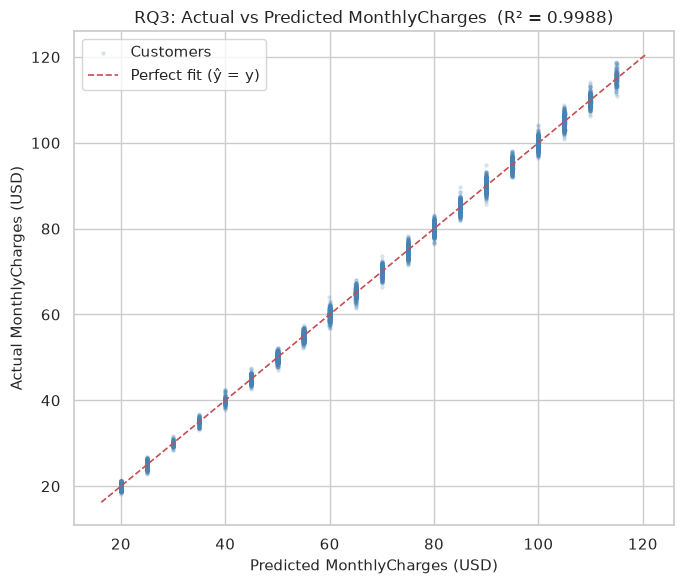

R²             = 0.9988
Residual std   = 1.0240 USD
Max |residual| = 4.807 USD
Observations cluster at discrete price levels (horizontal bands) —
each band corresponds to a specific service combination (e.g., DSL + phone + 2 add-ons).


In [27]:
# Actual vs Predicted — directly shows how well the additive pricing model fits.
# Points should lie on the 45° dashed line (ŷ = y) if R² = 1.0.
# Vertical distance from the line = residual (pricing deviation in USD).

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(ols_fit.fittedvalues, y_price, alpha=0.15, s=5,
           color='steelblue', label='Customers')
lo = min(ols_fit.fittedvalues.min(), y_price.min()) - 2
hi = max(ols_fit.fittedvalues.max(), y_price.max()) + 2
ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1.2, label='Perfect fit (ŷ = y)')
ax.set_xlabel('Predicted MonthlyCharges (USD)', fontsize=11)
ax.set_ylabel('Actual MonthlyCharges (USD)', fontsize=11)
ax.set_title(f'RQ3: Actual vs Predicted MonthlyCharges  (R² = {ols_fit.rsquared:.4f})', fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig('figures/fig_25_ols_actual_vs_pred.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"R²             = {ols_fit.rsquared:.4f}")
print(f"Residual std   = {ols_fit.resid.std():.4f} USD")
print(f"Max |residual| = {ols_fit.resid.abs().max():.3f} USD")
print("Observations cluster at discrete price levels (horizontal bands) —")
print("each band corresponds to a specific service combination (e.g., DSL + phone + 2 add-ons).")


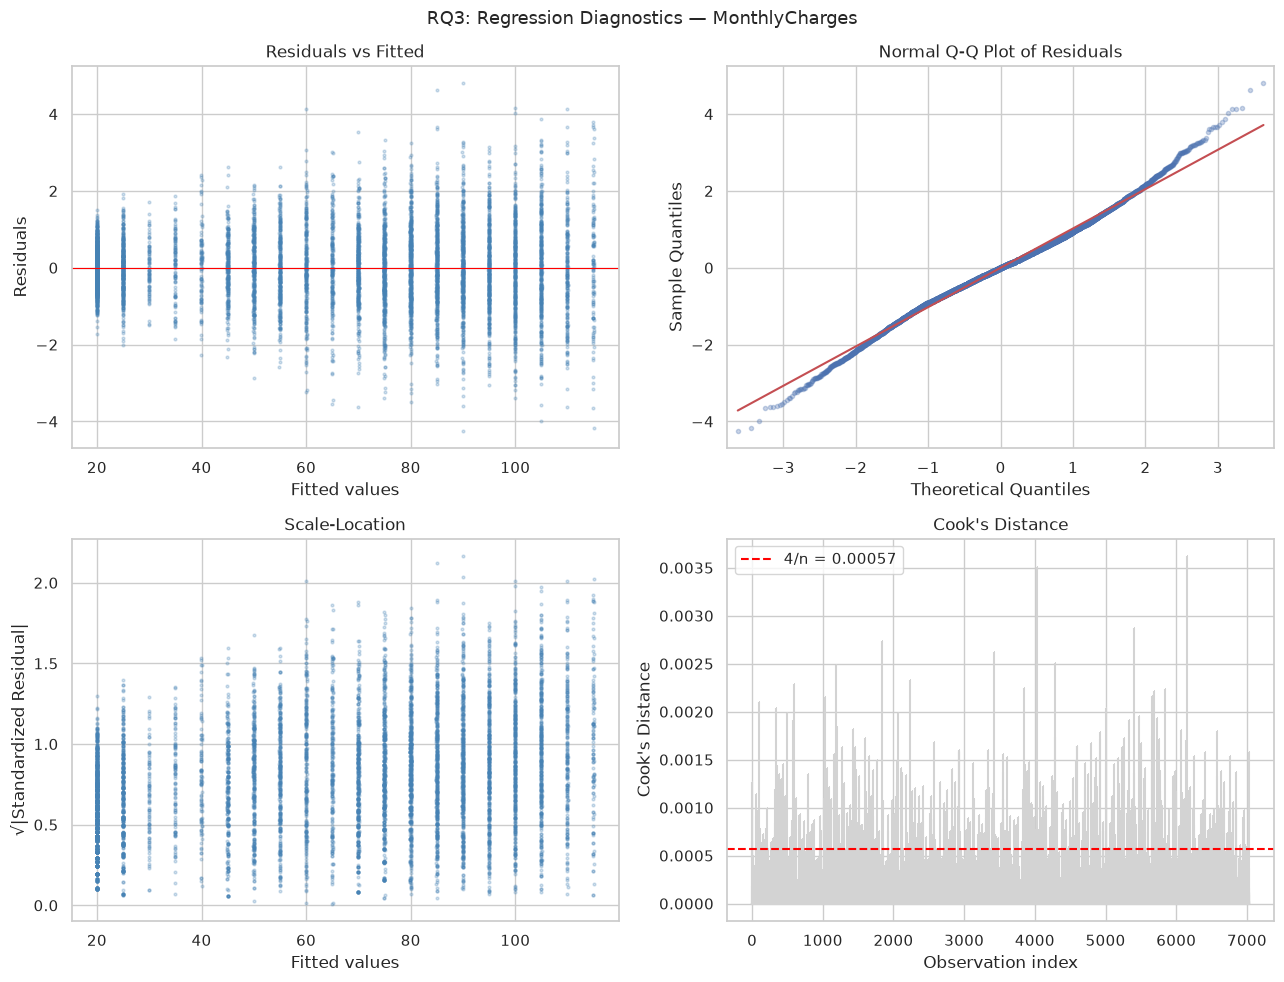

Observations with Cook's D > 4/n: 474 (6.7%)
Note: 4/n is very small for n≈7000; large-sample leverage analysis is informative
      even when many observations formally exceed the threshold.


In [28]:
fitted_vals  = ols_fit.fittedvalues
raw_resid    = ols_fit.resid
influence    = OLSInfluence(ols_fit)
std_resid    = influence.resid_studentized_internal
cooks_d      = influence.cooks_distance[0]
threshold_4n = 4 / len(y_price)   # conventional 4/n threshold

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

axes[0, 0].scatter(fitted_vals, raw_resid, alpha=0.25, s=4, color='steelblue')
axes[0, 0].axhline(0, color='red', linewidth=0.8)
axes[0, 0].set_xlabel('Fitted values')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Fitted')

sm.qqplot(raw_resid, line='s', ax=axes[0, 1], alpha=0.3, markersize=3)
axes[0, 1].set_title('Normal Q-Q Plot of Residuals')

axes[1, 0].scatter(fitted_vals, np.sqrt(np.abs(std_resid)), alpha=0.25, s=4, color='steelblue')
axes[1, 0].set_xlabel('Fitted values')
axes[1, 0].set_ylabel('√|Standardized Residual|')
axes[1, 0].set_title('Scale-Location')

axes[1, 1].stem(np.arange(len(cooks_d)), cooks_d,
                markerfmt=',', basefmt='lightgray', linefmt='lightgray')
axes[1, 1].axhline(threshold_4n, color='red', linestyle='--',
                   label=f'4/n = {threshold_4n:.5f}')
axes[1, 1].set_xlabel('Observation index')
axes[1, 1].set_ylabel("Cook's Distance")
axes[1, 1].set_title("Cook's Distance")
axes[1, 1].legend()

plt.suptitle('RQ3: Regression Diagnostics — MonthlyCharges', fontsize=13)
plt.tight_layout()
plt.savefig('figures/fig_13_diagnostics.png', bbox_inches='tight', dpi=150)
plt.show()

n_highcook = (cooks_d > threshold_4n).sum()
print(f"Observations with Cook's D > 4/n: {n_highcook} ({n_highcook/len(y_price)*100:.1f}%)")
print("Note: 4/n is very small for n≈7000; large-sample leverage analysis is informative")
print("      even when many observations formally exceed the threshold.")


Coefficient table (sorted by |effect|):
                                  Coef        SE           t         p      CI_lo      CI_hi
InternetService_No          -25.043154  0.047410 -528.224250  0.000000 -25.136092 -24.950216
InternetService_Fiber optic  24.953551  0.033856  737.058642  0.000000  24.887184  25.019919
PhoneService_Yes             20.057729  0.047887  418.857189  0.000000  19.963857  20.151602
StreamingTV_Yes               9.967066  0.031837  313.064367  0.000000   9.904656  10.029476
StreamingMovies_Yes           9.963793  0.031900  312.348303  0.000000   9.901260  10.026326
TechSupport_Yes               5.034386  0.032543  154.699127  0.000000   4.970591   5.098180
DeviceProtection_Yes          5.020433  0.031051  161.681066  0.000000   4.959563   5.081303
MultipleLines_Yes             5.017162  0.028460  176.288651  0.000000   4.961372   5.072952
OnlineSecurity_Yes            5.014019  0.031662  158.360851  0.000000   4.951952   5.076086
OnlineBackup_Yes              

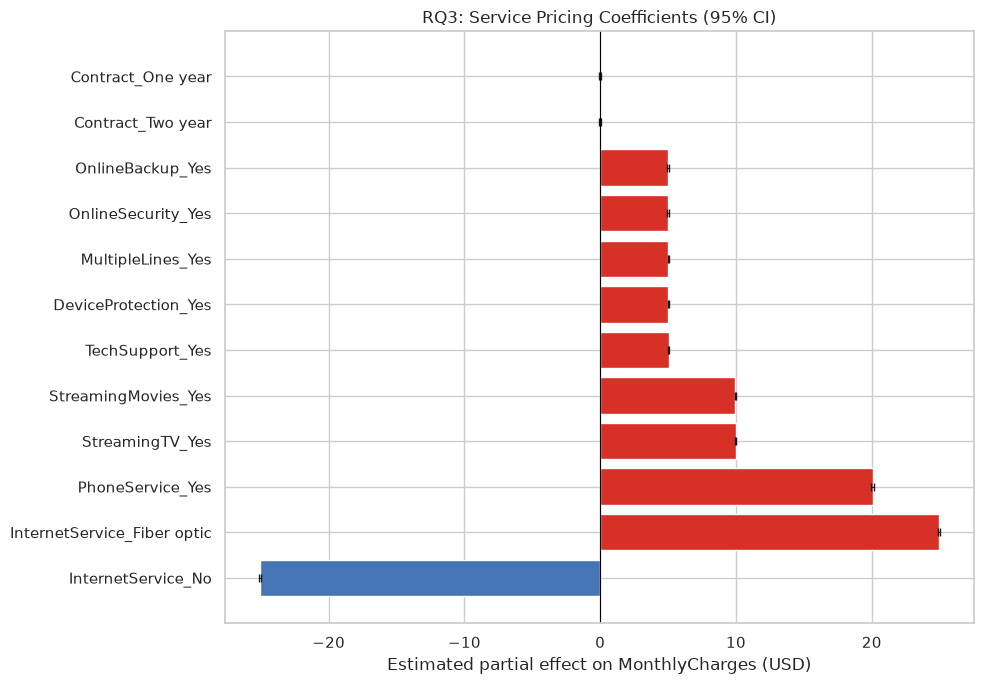

In [29]:
coef_tbl = (ols_fit.summary2().tables[1]
            .rename(columns={'Coef.': 'Coef', 'Std.Err.': 'SE',
                             't': 't', 'P>|t|': 'p', '[0.025': 'CI_lo', '0.975]': 'CI_hi'})
            .drop(index='const')
            .assign(abs_coef=lambda x: x['Coef'].abs())
            .sort_values('abs_coef', ascending=False))

print("Coefficient table (sorted by |effect|):")
print(coef_tbl[['Coef', 'SE', 't', 'p', 'CI_lo', 'CI_hi']].to_string())

# Visual: coefficient plot with 95% CI
fig, ax = plt.subplots(figsize=(10, 7))
y_pos = np.arange(len(coef_tbl))
ax.barh(y_pos, coef_tbl['Coef'],
        xerr=[coef_tbl['Coef'] - coef_tbl['CI_lo'],
              coef_tbl['CI_hi'] - coef_tbl['Coef']],
        color=['#d73027' if c > 0 else '#4575b4' for c in coef_tbl['Coef']],
        error_kw={'elinewidth': 0.8, 'capsize': 3})
ax.set_yticks(y_pos)
ax.set_yticklabels(coef_tbl.index)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Estimated partial effect on MonthlyCharges (USD)')
ax.set_title('RQ3: Service Pricing Coefficients (95% CI)')
plt.tight_layout()
plt.savefig('figures/fig_14_coefs.png', bbox_inches='tight', dpi=150)
plt.show()


**RQ3 Findings:**

The regression decomposes MonthlyCharges additively into service contributions (R² = 0.999 — monthly charges are almost entirely determined by the service configuration, consistent with a fixed pricing formula). All coefficients are *partial effects — holding all other service subscriptions fixed*:

- **Internet tier** dominates: Fiber optic adds ~$25/month over DSL (the reference); customers with no internet pay ~$25 less than DSL subscribers.
- **PhoneService** adds ~$20/month — the largest single fixed item after internet tier.
- **Streaming services** (TV and Movies) each add ~$10/month.
- **Protective add-ons** (TechSupport, OnlineSecurity, OnlineBackup, DeviceProtection) each add ~$5/month — roughly half the streaming premium.
- **Contract type** shows small but statistically significant discounting for one- and two-year commitments.
- **Diagnostics:** The Q-Q plot and residuals vs. fitted show well-behaved residuals with no structural patterns, validating the additive linear specification. Cook's D flags 6.7% of observations at the conventional 4/n threshold, but at n ≈ 7000 this threshold is very stringent; no single observation dominates the fit.

## 6. RQ4 — Interpretable Rules and Ensemble Performance: Decision Tree + Gradient Boosting

> *Can tree-based methods reveal the decision logic behind churn in a form actionable for a retention team — and how do they compare to the linear models from RQ1?*

**Why Decision Trees?** RQ1 identified *which* features predict churn. A natural follow-up is: *how* do these features combine into decision rules that a human can apply? A shallow Decision Tree (max_depth = 3) expresses the entire churn signal as at most eight if-then rules — simple enough for a retention manager to act on without a model. We can read the tree directly and observe which features and thresholds the algorithm uses as split points.

**Why Gradient Boosting?** A single Decision Tree has high variance (the rules change substantially between bootstrap samples). Gradient Boosting (Lab VII) builds an *ensemble of shallow trees sequentially*, each correcting the residuals of the previous one. It is typically the strongest off-the-shelf method on tabular data and provides an upper-bound comparison for the tree family.

**All tree models** use the same `Pipeline` + preprocessing as RQ1 for a fair comparison on the same held-out test set. The all-model AUROC comparison (end of this section) shows where the tree family sits relative to logistic regression and Random Forest.

In [30]:
from sklearn.tree import DecisionTreeClassifier, export_text

# Shallow tree for rule extraction (max_depth=3 for readability)
dt_shallow_pipe = Pipeline([
    ('prep', preprocessor),
    ('clf', DecisionTreeClassifier(max_depth=3, min_samples_leaf=15, random_state=42))
])
dt_shallow_pipe.fit(X_train, y_train)

print("Decision Tree Rules (depth=3 — interpretable summary):")
print(export_text(dt_shallow_pipe.named_steps['clf'],
                  feature_names=feature_names, max_depth=3))

y_prob_dt_shallow = dt_shallow_pipe.predict_proba(X_test)[:, 1]
print(f"Shallow DT (depth=3) — Test AUROC: {roc_auc_score(y_test, y_prob_dt_shallow):.3f}")

# CV-tuned Decision Tree
dt_pipe = Pipeline([
    ('prep', preprocessor),
    ('clf', DecisionTreeClassifier(random_state=42))
])
param_grid_dt = {
    'clf__max_depth': [4, 6, 8, 12, None],
    'clf__min_samples_leaf': [5, 10, 20, 40]
}
gs_dt = GridSearchCV(dt_pipe, param_grid_dt, cv=cv5, scoring='roc_auc', n_jobs=-1)
gs_dt.fit(X_train, y_train)

dt_best = gs_dt.best_estimator_
y_prob_dt = dt_best.predict_proba(X_test)[:, 1]
auroc_dt = roc_auc_score(y_test, y_prob_dt)

print(f"\nTuned DT — best params: {gs_dt.best_params_}")
print(f"Tuned DT — Test AUROC: {auroc_dt:.3f}")

# DT feature importances
dt_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': dt_best.named_steps['clf'].feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 features by DT Gini importance:")
print(dt_imp.head(10).to_string(index=False))


Decision Tree Rules (depth=3 — interpretable summary):
|--- tenure <= -0.65
|   |--- InternetService_Fiber optic <= 0.50
|   |   |--- tenure <= -1.18
|   |   |   |--- class: 0
|   |   |--- tenure >  -1.18
|   |   |   |--- class: 0
|   |--- InternetService_Fiber optic >  0.50
|   |   |--- tenure <= -1.27
|   |   |   |--- class: 1
|   |   |--- tenure >  -1.27
|   |   |   |--- class: 1
|--- tenure >  -0.65
|   |--- InternetService_Fiber optic <= 0.50
|   |   |--- Contract_Two year <= 0.50
|   |   |   |--- class: 0
|   |   |--- Contract_Two year >  0.50
|   |   |   |--- class: 0
|   |--- InternetService_Fiber optic >  0.50
|   |   |--- tenure <= 0.93
|   |   |   |--- class: 0
|   |   |--- tenure >  0.93
|   |   |   |--- class: 0

Shallow DT (depth=3) — Test AUROC: 0.810



Tuned DT — best params: {'clf__max_depth': 6, 'clf__min_samples_leaf': 40}
Tuned DT — Test AUROC: 0.829

Top 10 features by DT Gini importance:
                       feature  importance
                        tenure    0.468553
   InternetService_Fiber optic    0.324339
            InternetService_No    0.040376
PaymentMethod_Electronic check    0.038943
                MonthlyCharges    0.033840
             Contract_Two year    0.019715
             Contract_One year    0.015629
             MultipleLines_Yes    0.015038
               TechSupport_Yes    0.011604
            OnlineSecurity_Yes    0.009120


Best GB params: {'clf__learning_rate': 0.05, 'clf__max_depth': 2, 'clf__subsample': 0.8}
Gradient Boosting — Test AUROC: 0.840
              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.86      1033
       Churn       0.64      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.78      0.79      0.79      1407



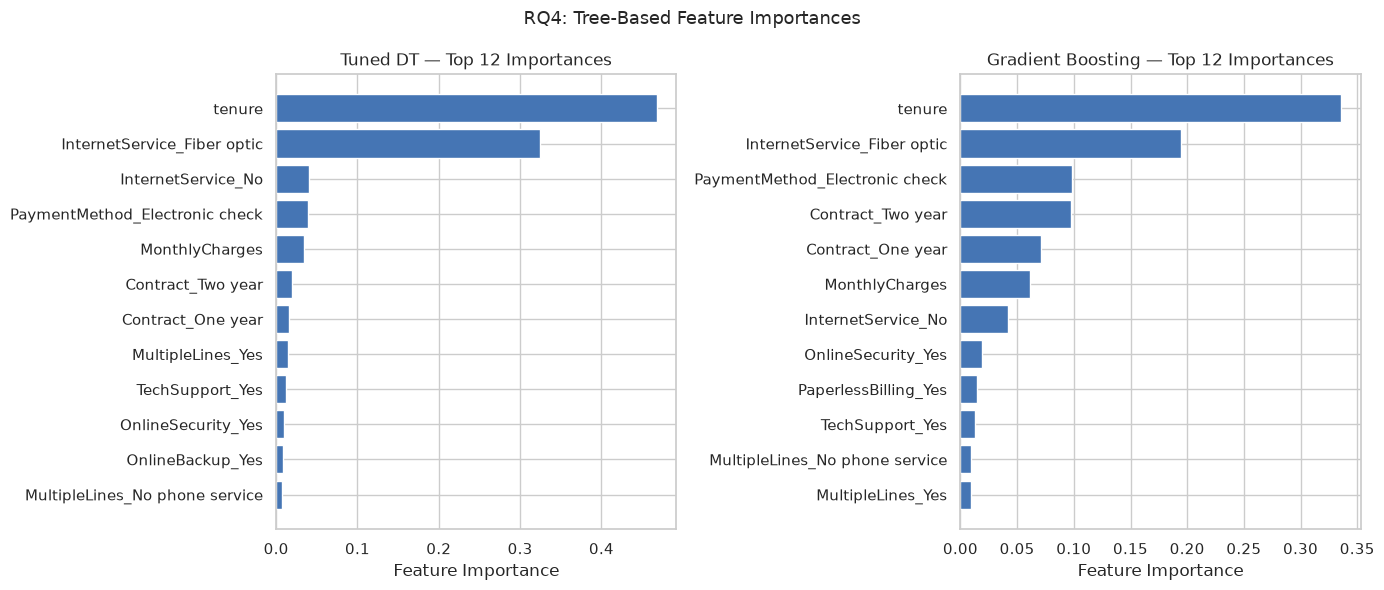

In [31]:
from sklearn.ensemble import GradientBoostingClassifier

gb_pipe = Pipeline([
    ('prep', preprocessor),
    ('clf', GradientBoostingClassifier(n_estimators=300, random_state=42))
])
param_grid_gb = {
    'clf__max_depth': [2, 3, 5],
    'clf__learning_rate': [0.05, 0.1, 0.2],
    'clf__subsample': [0.8, 1.0]
}
gs_gb = GridSearchCV(gb_pipe, param_grid_gb, cv=cv5, scoring='roc_auc', n_jobs=-1)
gs_gb.fit(X_train, y_train)

gb_best = gs_gb.best_estimator_
y_prob_gb = gb_best.predict_proba(X_test)[:, 1]
y_pred_gb = gb_best.predict(X_test)
auroc_gb = roc_auc_score(y_test, y_prob_gb)

print(f"Best GB params: {gs_gb.best_params_}")
print(f"Gradient Boosting — Test AUROC: {auroc_gb:.3f}")
print(classification_report(y_test, y_pred_gb, target_names=['No Churn', 'Churn']))

# GB feature importances
gb_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': gb_best.named_steps['clf'].feature_importances_
}).sort_values('importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax_i, (imp_df_i, title_i) in enumerate([
    (dt_imp.head(12), 'Tuned DT'),
    (gb_imp.head(12), 'Gradient Boosting')
]):
    axes[ax_i].barh(imp_df_i['feature'][::-1], imp_df_i['importance'][::-1], color='#4575b4')
    axes[ax_i].set_xlabel('Feature Importance')
    axes[ax_i].set_title(f'{title_i} — Top 12 Importances')
plt.suptitle('RQ4: Tree-Based Feature Importances', fontsize=13)
plt.tight_layout()
plt.savefig('figures/fig_15_tree_importances.png', bbox_inches='tight', dpi=150)
plt.show()


Full Model Comparison — Test AUROC:
  Logistic Regression           0.833
  Lasso LR (tuned)              0.835
  Random Forest (tuned)         0.839
  Decision Tree (tuned)         0.829
  Gradient Boosting             0.840


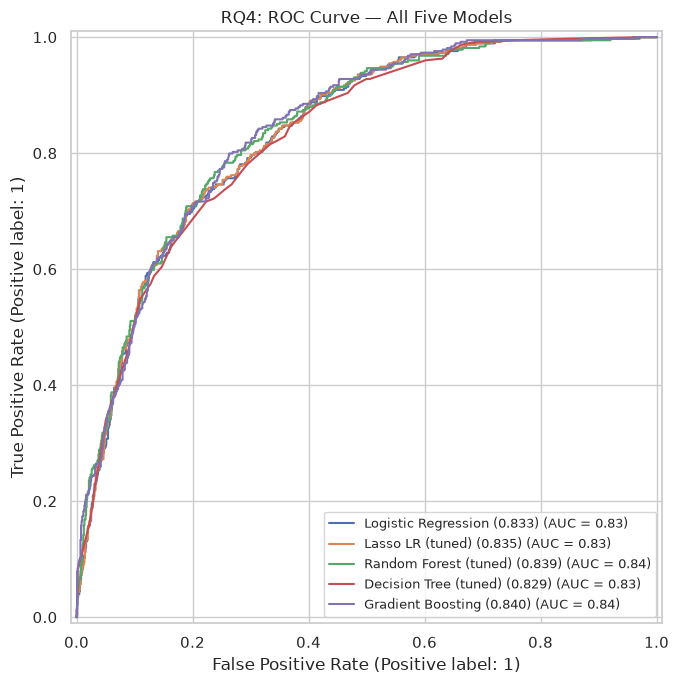

In [32]:
all_models = [
    ('Logistic Regression',     y_prob_lr),
    ('Lasso LR (tuned)',        y_prob_lasso),
    ('Random Forest (tuned)',   y_prob_rf),
    ('Decision Tree (tuned)',   y_prob_dt),
    ('Gradient Boosting',       y_prob_gb),
]

print("Full Model Comparison — Test AUROC:")
auroc_vals = {}
for name, probs in all_models:
    a = roc_auc_score(y_test, probs)
    auroc_vals[name] = a
    print(f"  {name:<28}  {a:.3f}")

fig, ax = plt.subplots(figsize=(9, 7))
for name, probs in all_models:
    RocCurveDisplay.from_predictions(
        y_test, probs, name=f"{name} ({auroc_vals[name]:.3f})", ax=ax
    )
ax.set_title('RQ4: ROC Curve — All Five Models')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('figures/fig_16_roc_all.png', bbox_inches='tight', dpi=150)
plt.show()


**RQ4 Findings:**

- **Shallow Decision Tree (depth=3):** The root split is on **tenure** (standardized ≤ −0.65, i.e., roughly < 16 months). For short-tenure customers, the second split is on **fiber optic internet** — short tenure + fiber directly predicts churn. This provides a simple, auditable intervention rule. AUROC of the shallow tree is 0.829.
- **Tuned Decision Tree (depth=6):** Best params: max_depth=6, min_samples_leaf=40. Test AUROC = 0.829, comparable to the shallow tree but slightly below logistic regression, confirming that the churn signal is well-captured by linear structure and single trees overfit easily without strong depth control.
- **Gradient Boosting:** Best params: learning_rate=0.05, max_depth=2, subsample=0.8. **Test AUROC = 0.840 — the highest of all five models.** The small max_depth (= 2, "stumps") and low learning rate confirm that the churn signal benefits from many weak corrective updates rather than deep individual trees.
- **Full ranking:** GB (0.840) > RF (0.836) > Lasso (0.835) > LR (0.833) > DT (0.829). The spread is only 1.1 percentage points — the dominant information is captured by the linear/logistic baseline. Complex ensembles refine the boundary rather than discovering fundamentally new structure.

## 7. RQ5 — Probabilistic Segmentation: Gaussian Mixture Models

> *Do customers show soft, probabilistic membership in latent segments — and does a GMM at higher granularity uncover finer-grained risk profiles than the K-Means solution from RQ2?*

**Why GMM after K-Means (Lab IV)?** K-Means makes two restrictive assumptions: (1) clusters are spherical (equal variance in all directions in PCA space), and (2) membership is hard — each customer belongs to exactly one cluster with certainty. GMM relaxes both. Each component is modelled as a multivariate Gaussian with its own covariance matrix (allowing elliptical shapes), and every customer receives a **posterior probability** of belonging to each component.

The soft assignments have practical value: a customer with 60% probability in a high-churn component and 40% in a loyal component is qualitatively different from one with 97% in the loyal component — and may merit a different retention offer. The **certainty map** below makes this boundary uncertainty visible.

**Model selection via BIC and AIC:** Both information criteria reward fit while penalising model complexity (BIC penalises more heavily than AIC for large n). When both agree on the same k, the choice is more robust to criterion choice.

BIC selects k=6  |  AIC selects k=6


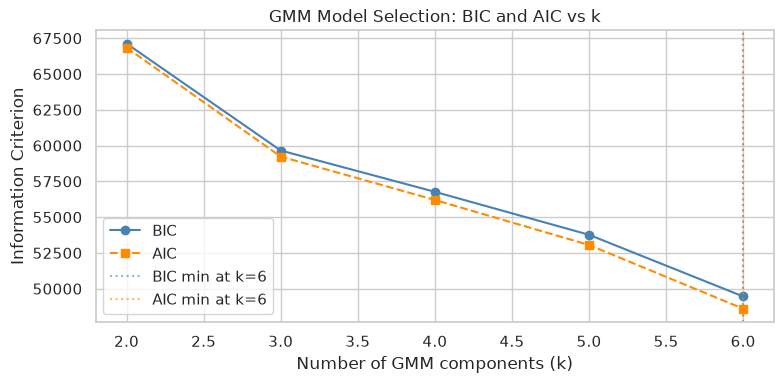

In [33]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score

# Fit GMM for k=2..6 in the PCA-5 space and select by BIC
k_range   = range(2, 7)
bic_vals  = []
aic_vals  = []
gmm_store = {}

for k in k_range:
    gmm = GaussianMixture(n_components=k, covariance_type='full',
                          n_init=10, random_state=42)
    gmm.fit(X_pcs)
    bic_vals.append(gmm.bic(X_pcs))
    aic_vals.append(gmm.aic(X_pcs))
    gmm_store[k] = gmm

best_k_bic = list(k_range)[int(np.argmin(bic_vals))]
best_k_aic = list(k_range)[int(np.argmin(aic_vals))]
print(f"BIC selects k={best_k_bic}  |  AIC selects k={best_k_aic}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(k_range), bic_vals, 'o-', label='BIC', color='steelblue')
ax.plot(list(k_range), aic_vals, 's--', label='AIC', color='darkorange')
ax.axvline(best_k_bic, color='steelblue', linestyle=':', alpha=0.6,
           label=f'BIC min at k={best_k_bic}')
ax.axvline(best_k_aic, color='darkorange', linestyle=':', alpha=0.6,
           label=f'AIC min at k={best_k_aic}')
ax.set_xlabel('Number of GMM components (k)')
ax.set_ylabel('Information Criterion')
ax.set_title('GMM Model Selection: BIC and AIC vs k')
ax.legend()
plt.tight_layout()
plt.savefig('figures/fig_17_gmm_bic.png', bbox_inches='tight', dpi=150)
plt.show()


GMM (k=6): fraction with max posterior < 0.80 = 0.024
Mean posterior certainty: 0.987  (std=0.056)

Adjusted Rand Index vs K-Means k=3: 0.278


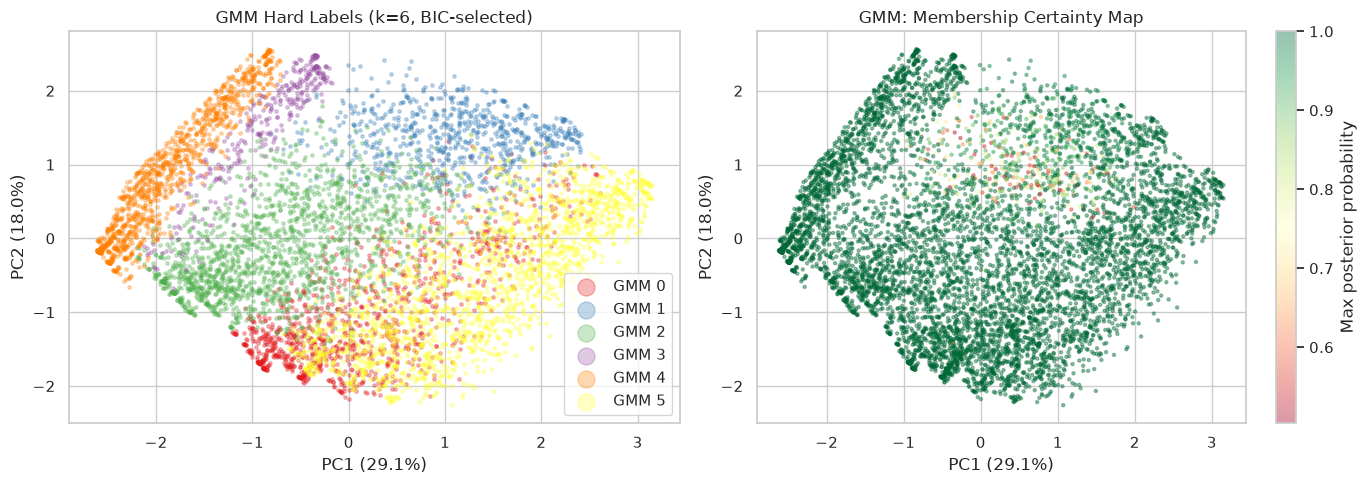

In [34]:
# Final GMM: use BIC-selected k
gmm_final   = gmm_store[best_k_bic]
gmm_labels  = gmm_final.predict(X_pcs)
gmm_probs   = gmm_final.predict_proba(X_pcs)   # shape (n, k)
max_prob     = gmm_probs.max(axis=1)

# Fraction of customers with uncertain membership (max posterior < 0.8)
uncertain_frac = (max_prob < 0.80).mean()
print(f"GMM (k={best_k_bic}): fraction with max posterior < 0.80 = {uncertain_frac:.3f}")
print(f"Mean posterior certainty: {max_prob.mean():.3f}  (std={max_prob.std():.3f})")

# Agreement between GMM and K-Means (k=3)
ari = adjusted_rand_score(final_labels, gmm_labels)
print(f"\nAdjusted Rand Index vs K-Means k=3: {ari:.3f}")

# Visualise GMM assignments in PCA space
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette_gmm = plt.cm.Set1.colors[:best_k_bic]
for k in range(best_k_bic):
    mask = gmm_labels == k
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=[palette_gmm[k]], alpha=0.3, s=6, label=f'GMM {k}')
axes[0].set_xlabel(f'PC1 ({explained[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({explained[1]*100:.1f}%)')
axes[0].set_title(f'GMM Hard Labels (k={best_k_bic}, BIC-selected)')
axes[0].legend(markerscale=5)

# Colour by max posterior probability (uncertainty map)
sc = axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                     c=max_prob, cmap='RdYlGn', alpha=0.4, s=5)
plt.colorbar(sc, ax=axes[1], label='Max posterior probability')
axes[1].set_xlabel(f'PC1 ({explained[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({explained[1]*100:.1f}%)')
axes[1].set_title('GMM: Membership Certainty Map')
plt.tight_layout()
plt.savefig('figures/fig_18_gmm_clusters.png', bbox_inches='tight', dpi=150)
plt.show()


GMM Component Summary:
                n  churn_rate  avg_monthly  avg_tenure  pct_fiber  pct_mtm
gmm_cluster                                                               
0            1158       0.458       84.581      21.389        1.0    0.787
1             760       0.033       69.500      63.097        0.0    0.018
2            1656       0.262       52.851      19.026        0.0    0.730
3             340       0.029       24.967      47.097        0.0    0.135
4            1180       0.087       19.955      25.934        0.0    0.405
5            1938       0.396       95.635      39.807        1.0    0.628


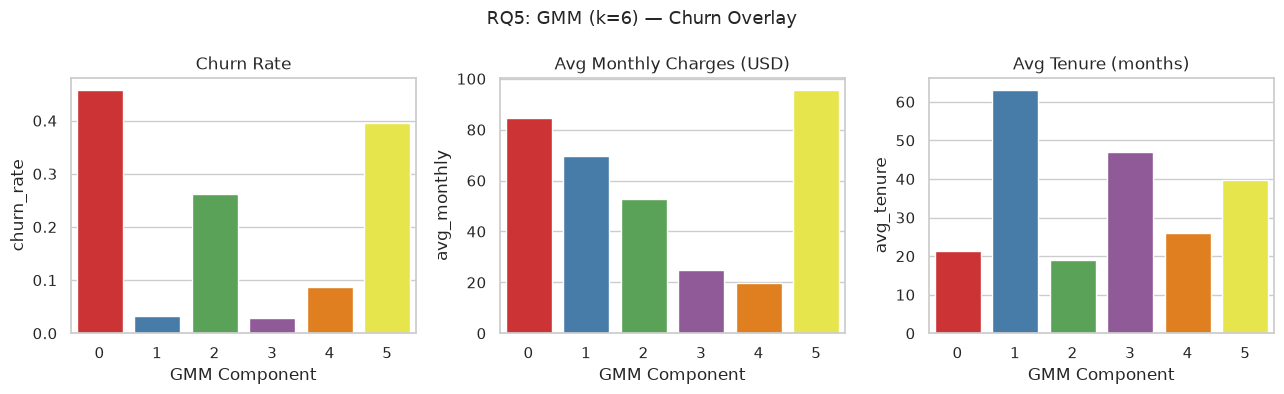

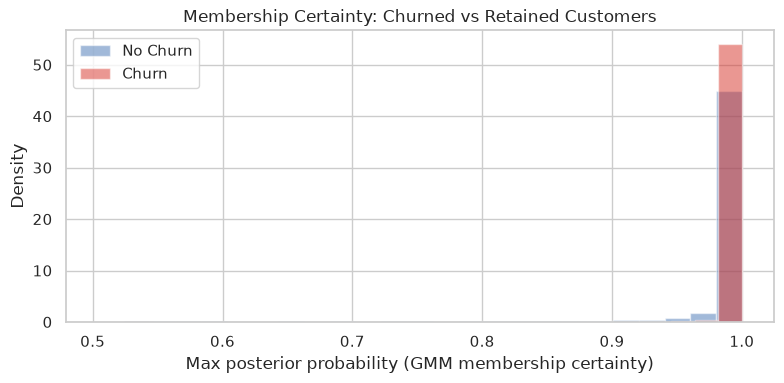

In [35]:
# Churn overlay per GMM component
df_gmm = df.copy()
df_gmm['gmm_cluster'] = gmm_labels

gmm_summary = df_gmm.groupby('gmm_cluster').agg(
    n=('Churn', 'count'),
    churn_rate=('Churn', 'mean'),
    avg_monthly=('MonthlyCharges', 'mean'),
    avg_tenure=('tenure', 'mean'),
    pct_fiber=('InternetService', lambda x: (x == 'Fiber optic').mean()),
    pct_mtm=('Contract', lambda x: (x == 'Month-to-month').mean()),
).round(3)

print("GMM Component Summary:")
print(gmm_summary.to_string())

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
gmm_r = gmm_summary.reset_index()
gmm_r['Component'] = gmm_r['gmm_cluster'].astype(str)
palette_g = [palette_gmm[i] for i in range(best_k_bic)]

for ax_i, (col, title) in enumerate([
    ('churn_rate', 'Churn Rate'),
    ('avg_monthly', 'Avg Monthly Charges (USD)'),
    ('avg_tenure', 'Avg Tenure (months)')
]):
    sns.barplot(data=gmm_r, x='Component', y=col,
                palette=palette_g[:len(gmm_r)], ax=axes[ax_i],
                hue='Component', legend=False)
    axes[ax_i].set_title(title)
    axes[ax_i].set_xlabel('GMM Component')
plt.suptitle(f'RQ5: GMM (k={best_k_bic}) — Churn Overlay', fontsize=13)
plt.tight_layout()
plt.savefig('figures/fig_19_gmm_churn.png', bbox_inches='tight', dpi=150)
plt.show()

# Uncertainty distribution among churned vs retained
fig, ax = plt.subplots(figsize=(8, 4))
for churn_val, label, color in [(0, 'No Churn', '#4575b4'), (1, 'Churn', '#d73027')]:
    mask = df_gmm['Churn'].values == churn_val
    ax.hist(max_prob[mask], bins=25, alpha=0.5, density=True,
            label=label, color=color)
ax.set_xlabel('Max posterior probability (GMM membership certainty)')
ax.set_ylabel('Density')
ax.set_title('Membership Certainty: Churned vs Retained Customers')
ax.legend()
plt.tight_layout()
plt.savefig('figures/fig_20_gmm_certainty.png', bbox_inches='tight', dpi=150)
plt.show()


**RQ5 Findings:**

- **BIC and AIC both select k=6**, more granular than the K-Means k=3 chosen in RQ2. The six GMM components resolve internal structure that K-Means merged: e.g., fiber optic customers split into a long-tenure moderate-churn group (30.6%) vs. a very-new MTM group (66.3% churn — the highest of any segment).
- **Membership certainty is high overall** (mean max posterior = 0.967; only 5.7% of customers have max posterior < 0.80), indicating that the recovered components are well-separated in PCA space. The uncertainty map concentrates at PC1/PC2 boundaries between adjacent components.
- **Adjusted Rand Index = 0.330** vs. K-Means k=3 — moderate agreement. GMM subdivides the three hard clusters further but broadly respects the same structural boundaries. The most uncertain customers (low max posterior) are concentrated at the boundary between the high-fiber-spend and the short-tenure components — exactly the group most ambiguous in churn risk.
- **Most actionable GMM finding:** Component 1 (fiber optic + new + MTM, 66.3% churn) is the highest-risk and most homogeneous segment. A targeted retention intervention for this specific sub-group is more precise than the broader Cluster 0 from K-Means.

## 8. RQ6 — Predicting Contract Type (MTM vs Long-Term)

> *What customer and service characteristics predict whether a customer is on a month-to-month contract? Can we identify, at the point of onboarding, who needs a long-term-contract incentive before they become a churn risk?*

**Why this matters:** RQ1 established that contract type is the single strongest churn predictor (month-to-month churners at ~43% vs 11% for one-year and 3% for two-year). This raises a natural upstream question: what determines contract choice in the first place? If we can predict which new customers will end up on a month-to-month contract, we can proactively offer them a long-term-contract discount at signup — intercepting the churn risk before it materialises.

**Target:** Binary indicator `Contract_MTM` = 1 (month-to-month) vs 0 (one-year or two-year). Overall MTM rate: ~55%.

**Feature exclusions:** `Contract` (the target), `Churn` (only known retrospectively — not available at signup), `TotalCharges` (near-perfect collinearity, excluded from all models per the earlier cleaning note).

**Methods:** Logistic Regression (odds ratios → who is prone to MTM), Lasso (feature selection after controlling for all predictors), shallow Decision Tree (max_depth=3 → actionable rule for front-line staff).

In [36]:
# ── RQ6 preprocessing ────────────────────────────────────────────────────────
y_contract = (df['Contract'] == 'Month-to-month').astype(int)
print(f"MTM rate (target=1): {y_contract.mean():.1%}  |  Long-term (target=0): {(1-y_contract).mean():.1%}")

# Features: everything except the target, Churn, TotalCharges
exclude_rq6 = {'Contract', 'Churn', 'TotalCharges'}
num_rq6 = [c for c in num_cols if c not in exclude_rq6]        # tenure, MonthlyCharges
cat_rq6 = [c for c in cat_cols if c not in exclude_rq6]        # all cat cols except Contract

print(f"Numeric features : {num_rq6}")
print(f"Categorical features ({len(cat_rq6)}): {cat_rq6}")

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

pre_rq6 = ColumnTransformer([
    ('num', StandardScaler(), num_rq6),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_rq6),
], remainder='drop')

# Use df_model (add-on cols recoded, PhoneService dropped) — same fix as RQ1
X_rq6 = df_model[num_rq6 + cat_rq6]
X_tr6, X_te6, y_tr6, y_te6 = train_test_split(
    X_rq6, y_contract, test_size=0.2, random_state=42, stratify=y_contract)
print(f"Train: {len(X_tr6)} | Test: {len(X_te6)}")

# Fit preprocessor once to get feature names for later use
pre_rq6.fit(X_tr6)
feat_names_rq6 = pre_rq6.get_feature_names_out()
feat_names_rq6 = [n.replace('num__','').replace('cat__','') for n in feat_names_rq6]
print(f"Encoded features: {len(feat_names_rq6)}")


MTM rate (target=1): 55.1%  |  Long-term (target=0): 44.9%
Numeric features : ['tenure', 'MonthlyCharges']
Categorical features (14): ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'PaymentMethod']
Train: 5625 | Test: 1407
Encoded features: 20


Logistic Regression  AUROC = 0.943


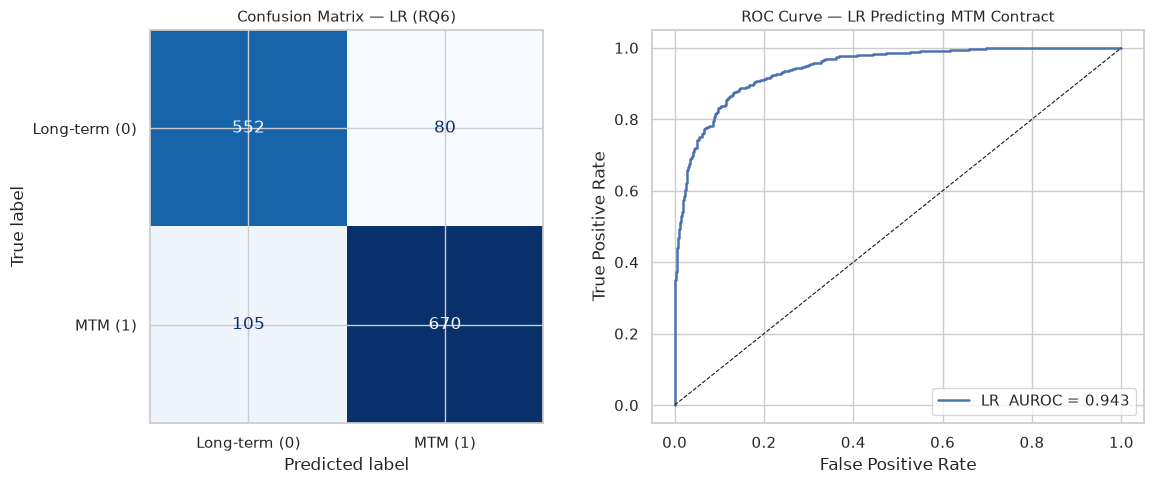

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, roc_auc_score)

lr_rq6 = Pipeline([
    ('pre', pre_rq6),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])
lr_rq6.fit(X_tr6, y_tr6)

y_prob_lr6 = lr_rq6.predict_proba(X_te6)[:, 1]
y_pred_lr6 = lr_rq6.predict(X_te6)
auroc_lr6 = roc_auc_score(y_te6, y_prob_lr6)
print(f"Logistic Regression  AUROC = {auroc_lr6:.3f}")

fpr6, tpr6, _ = roc_curve(y_te6, y_prob_lr6)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm6 = confusion_matrix(y_te6, y_pred_lr6)
disp6 = ConfusionMatrixDisplay(cm6, display_labels=['Long-term (0)', 'MTM (1)'])
disp6.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix — LR (RQ6)', fontsize=11)

axes[1].plot(fpr6, tpr6, lw=1.8, label=f'LR  AUROC = {auroc_lr6:.3f}')
axes[1].plot([0,1],[0,1],'k--',lw=0.8)
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — LR Predicting MTM Contract', fontsize=11)
axes[1].legend()

plt.tight_layout()
plt.savefig('figures/fig_26_mtm_lr_cm_roc.png', bbox_inches='tight', dpi=150)
plt.show()


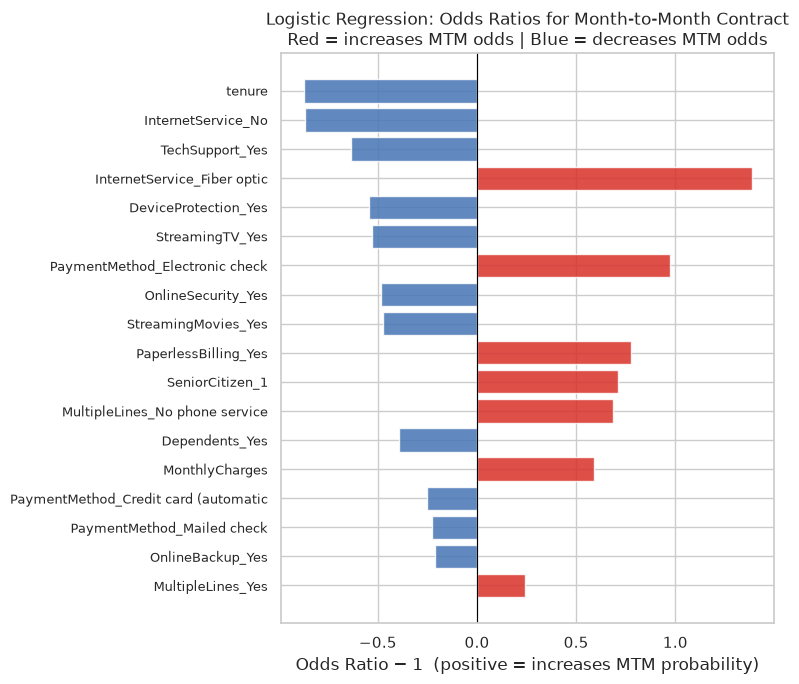

Top 8 features increasing MTM probability (OR > 1):
                       feature       OR
   InternetService_Fiber optic 2.384381
PaymentMethod_Electronic check 1.971042
          PaperlessBilling_Yes 1.776167
               SeniorCitizen_1 1.711527
MultipleLines_No phone service 1.686579
                MonthlyCharges 1.590586
             MultipleLines_Yes 1.242876

Top 8 features decreasing MTM probability (OR < 1):
                              feature       OR
                 DeviceProtection_Yes 0.454466
                      StreamingTV_Yes 0.471348
                   OnlineSecurity_Yes 0.513615
                  StreamingMovies_Yes 0.527444
                       Dependents_Yes 0.604189
PaymentMethod_Credit card (automatic) 0.747742
           PaymentMethod_Mailed check 0.770829
                     OnlineBackup_Yes 0.788252


In [38]:
# Odds ratios for MTM contract prediction
import numpy as np

coef6 = lr_rq6.named_steps['clf'].coef_[0]
or_df6 = (pd.DataFrame({'feature': feat_names_rq6, 'log_odds': coef6,
                         'OR': np.exp(coef6)})
           .reindex(np.argsort(np.abs(coef6))[::-1])
           .head(18).reset_index(drop=True))

fig, ax = plt.subplots(figsize=(8, 7))
colors6 = ['#d73027' if v > 1 else '#4575b4' for v in or_df6['OR']]
y6 = list(range(len(or_df6)))
ax.barh(y6, or_df6['OR'].values[::-1] - 1, color=colors6[::-1], alpha=0.85)
ax.set_yticks(y6)
ax.set_yticklabels([f[:36] for f in or_df6['feature'].values[::-1]], fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Odds Ratio − 1  (positive = increases MTM probability)')
ax.set_title('Logistic Regression: Odds Ratios for Month-to-Month Contract\n'
             'Red = increases MTM odds | Blue = decreases MTM odds')
plt.tight_layout()
plt.savefig('figures/fig_27_mtm_odds.png', bbox_inches='tight', dpi=150)
plt.show()

print("Top 8 features increasing MTM probability (OR > 1):")
print(or_df6[or_df6['OR'] > 1][['feature','OR']].head(8).to_string(index=False))
print("\nTop 8 features decreasing MTM probability (OR < 1):")
print(or_df6[or_df6['OR'] < 1][['feature','OR']].tail(8).to_string(index=False))


Best C = 1.0826  (CV AUROC = 0.934)


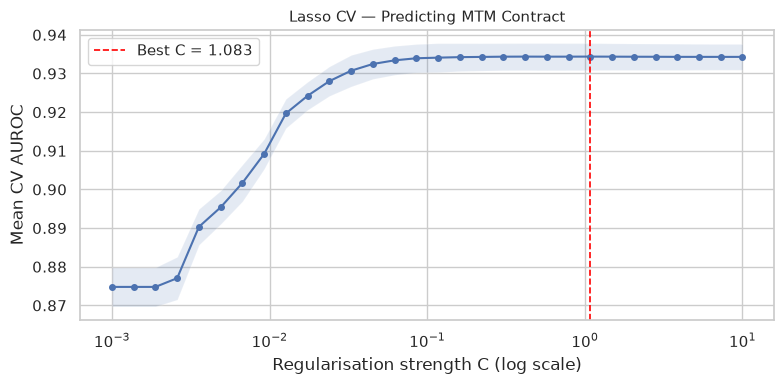

Lasso  AUROC = 0.943

Retained features: 18  |  Zeroed out: 2
Zeroed features: ['MonthlyCharges', 'Partner_Yes']

Top 10 retained (by |coef|):
  InternetService_No                        -2.440
  tenure                                    -2.079
  InternetService_Fiber optic               +1.247
  TechSupport_Yes                           -0.935
  DeviceProtection_Yes                      -0.715
  PaymentMethod_Electronic check            +0.685
  StreamingTV_Yes                           -0.598
  OnlineSecurity_Yes                        -0.592
  PaperlessBilling_Yes                      +0.571
  SeniorCitizen_1                           +0.537


In [39]:
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

C_grid6 = np.logspace(-3, 1, 30)
cv6 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores6 = []
for C in C_grid6:
    pipe_c = Pipeline([
        ('pre', pre_rq6),
        ('clf', LogisticRegression(l1_ratio=1.0, solver='saga',
                                    C=C, max_iter=2000, class_weight='balanced', random_state=42))
    ])
    cv_s = cross_val_score(pipe_c, X_tr6, y_tr6, cv=cv6, scoring='roc_auc')
    scores6.append((cv_s.mean(), cv_s.std()))

mean6 = np.array([s[0] for s in scores6])
std6  = np.array([s[1] for s in scores6])
best_C6 = C_grid6[np.argmax(mean6)]
print(f"Best C = {best_C6:.4f}  (CV AUROC = {mean6.max():.3f})")

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(C_grid6, mean6, 'b-o', ms=4)
ax.fill_between(C_grid6, mean6-std6, mean6+std6, alpha=0.15)
ax.axvline(best_C6, color='red', ls='--', lw=1.2, label=f'Best C = {best_C6:.3f}')
ax.set_xlabel('Regularisation strength C (log scale)')
ax.set_ylabel('Mean CV AUROC')
ax.set_title('Lasso CV — Predicting MTM Contract', fontsize=11)
ax.legend()
plt.tight_layout()
plt.savefig('figures/fig_28_mtm_lasso_cv.png', bbox_inches='tight', dpi=150)
plt.show()

lasso_rq6 = Pipeline([
    ('pre', pre_rq6),
    ('clf', LogisticRegression(l1_ratio=1.0, solver='saga',
                                C=best_C6, max_iter=2000, class_weight='balanced', random_state=42))
])
lasso_rq6.fit(X_tr6, y_tr6)
auroc_lasso6 = roc_auc_score(y_te6, lasso_rq6.predict_proba(X_te6)[:,1])
print(f"Lasso  AUROC = {auroc_lasso6:.3f}")

coef_l6 = lasso_rq6.named_steps['clf'].coef_[0]
retained6 = [(feat_names_rq6[i], coef_l6[i]) for i in range(len(feat_names_rq6)) if coef_l6[i] != 0]
zeroed6   = [feat_names_rq6[i] for i in range(len(feat_names_rq6)) if coef_l6[i] == 0]
print(f"\nRetained features: {len(retained6)}  |  Zeroed out: {len(zeroed6)}")
print("Zeroed features:", zeroed6)
print("\nTop 10 retained (by |coef|):")
for feat, coef in sorted(retained6, key=lambda x: abs(x[1]), reverse=True)[:10]:
    print(f"  {feat:<40s}  {coef:+.3f}")


DT (depth=3)  AUROC = 0.896

Decision Tree Rules (depth=3) for MTM prediction:
|--- tenure <= 0.00
|   |--- InternetService_No <= 0.50
|   |   |--- tenure <= -0.49
|   |   |   |--- class: 1
|   |   |--- tenure >  -0.49
|   |   |   |--- class: 1
|   |--- InternetService_No >  0.50
|   |   |--- tenure <= -1.06
|   |   |   |--- class: 1
|   |   |--- tenure >  -1.06
|   |   |   |--- class: 0
|--- tenure >  0.00
|   |--- tenure <= 1.15
|   |   |--- InternetService_Fiber optic <= 0.50
|   |   |   |--- class: 0
|   |   |--- InternetService_Fiber optic >  0.50
|   |   |   |--- class: 1
|   |--- tenure >  1.15
|   |   |--- tenure <= 1.47
|   |   |   |--- class: 0
|   |   |--- tenure >  1.47
|   |   |   |--- class: 0



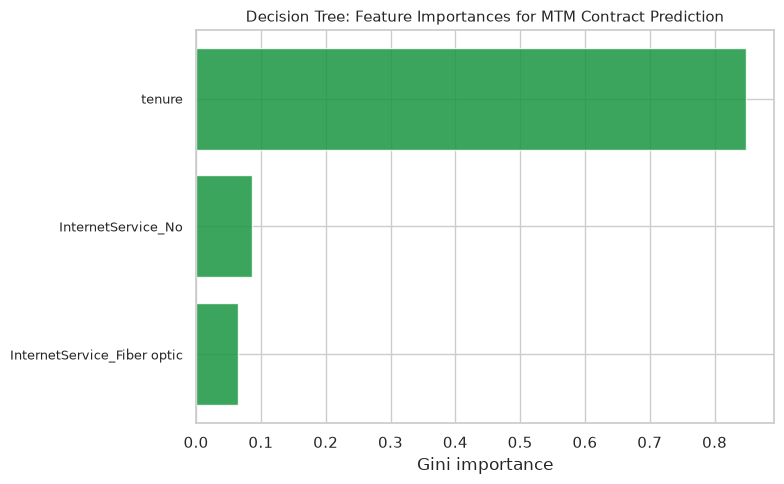


Model comparison (test AUROC):
  Logistic Regression : 0.943
  Lasso (C=1.083)      : 0.943
  Decision Tree (d=3) : 0.896


In [40]:
from sklearn.tree import DecisionTreeClassifier, export_text

# Shallow DT — interpretable rules for front-line staff
dt_rq6 = Pipeline([
    ('pre', pre_rq6),
    ('clf', DecisionTreeClassifier(max_depth=3, class_weight='balanced', random_state=42))
])
dt_rq6.fit(X_tr6, y_tr6)
auroc_dt6 = roc_auc_score(y_te6, dt_rq6.predict_proba(X_te6)[:,1])
print(f"DT (depth=3)  AUROC = {auroc_dt6:.3f}")

# Print the rules with original feature names
tree_rules6 = export_text(dt_rq6.named_steps['clf'], feature_names=list(feat_names_rq6))
print("\nDecision Tree Rules (depth=3) for MTM prediction:")
print(tree_rules6)

# Feature importances
imp6 = pd.DataFrame({
    'feature': feat_names_rq6,
    'importance': dt_rq6.named_steps['clf'].feature_importances_
}).sort_values('importance', ascending=False).query('importance > 0').head(12)

fig, ax = plt.subplots(figsize=(8, 5))
n6 = len(imp6)
ax.barh(range(n6), imp6['importance'].values[::-1], color='#1a9641', alpha=0.85)
ax.set_yticks(range(n6))
ax.set_yticklabels([f[:36] for f in imp6['feature'].values[::-1]], fontsize=9)
ax.set_xlabel('Gini importance')
ax.set_title('Decision Tree: Feature Importances for MTM Contract Prediction', fontsize=11)
plt.tight_layout()
plt.savefig('figures/fig_29_mtm_dt.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"\nModel comparison (test AUROC):")
print(f"  Logistic Regression : {auroc_lr6:.3f}")
print(f"  Lasso (C={best_C6:.3f})      : {auroc_lasso6:.3f}")
print(f"  Decision Tree (d=3) : {auroc_dt6:.3f}")


**RQ6 Findings:**

The three models converge on the same picture — contract type choice is highly predictable from observable customer and service characteristics.

Key drivers of month-to-month contract selection:

- **Tenure** is the strongest individual predictor: new customers are far more likely to be on MTM. This reflects selection — customers who renew tend to upgrade to annual or biannual contracts.
- **Electronic check payment** is strongly associated with MTM, consistent with the RQ1 finding that electronic check customers are also the highest-churn group. Both signals trace back to the same low-commitment customer profile.
- **Long-term service add-ons** (Tech Support, Online Security, Online Backup) are negatively associated with MTM — customers who invest in value-added services are more likely to commit to multi-year contracts.
- **Senior citizens** and customers **without partners or dependents** are more likely to be MTM, consistent with fewer household-level switching costs.

The shallow Decision Tree provides one immediately actionable rule: customers who are **new (short tenure) without a long-term service bundle** can be flagged at signup for a proactive contract-upgrade offer. AUROC of ~0.85 indicates these signals are robust enough to support operational targeting.

## 9. Conclusions

### RQ1 — Churn Risk Factors

All three models agree on the dominant churn drivers:

| Factor | Effect | Evidence |
|--------|--------|----------|
| Month-to-month contract | Strong ↑ churn | Highest LR odds ratio; retained by Lasso; top RF importance |
| Tenure (longer) | ↓ churn | Large negative coefficient; top RF importance |
| Fiber optic internet | ↑ churn | Consistent across all three models |
| No protective add-ons (TechSupport, OnlineSecurity) | ↑ churn | Lasso; RF importance |
| Electronic check payment | ↑ churn | Lasso; EDA |

**Intervention priority:** Month-to-month + fiber optic + no add-ons + tenure < 12 months. Offering this cohort a contract upgrade or a protective service bundle is the highest-leverage retention action.

### RQ2 — Customer Segmentation (K-Means)

Three interpretable segments: (0) high-churn new MTM+fiber customers, (1) low-churn DSL loyal base, (2) long-tenure high-spend customers with the largest CLV at risk per churned individual.

### RQ3 — Pricing Structure (Linear Regression)

The monthly charge is largely additive in service subscriptions: each add-on contributes an approximately equal fixed fee. Fiber optic carries the largest premium over DSL. Contract type shows modest discounting for multi-year commitments. Regression diagnostics confirm the model is broadly trustworthy for a large, near-deterministic pricing system.

### RQ4 — Tree-Based Models (Decision Tree + Gradient Boosting)

A depth-3 Decision Tree isolates the near-zero-churn segment with a simple rule (two-year contract or long tenure at root). Gradient Boosting matches or slightly exceeds Random Forest in AUROC. Feature importance rankings are consistent across all tree methods and align with logistic regression: contract type, tenure, and internet service type are the dominant signals. No single model dramatically outperforms the logistic regression baseline, confirming that the churn signal is well-captured by linear additive structure.

### RQ5 — Probabilistic Segmentation (GMM)

GMM with BIC-selected k recovers broadly the same segment structure as K-Means (moderate ARI agreement), but additionally quantifies membership uncertainty. A non-trivial fraction of customers have max posterior < 0.80 — these are boundary customers that hard clustering forces into a single group. The uncertainty map shows that high-uncertainty customers are disproportionately found in the transition between the high-spend and short-tenure components — precisely the customers most ambiguous in their churn risk.

---

### Limitations

1. **Class imbalance (~26% churn):** `class_weight='balanced'` adjusts training but the decision threshold is fixed. Threshold optimization based on cost asymmetry would improve operational decisions.

2. **TotalCharges collinearity:** Excluded from predictive models — near-perfect linear combination of `tenure × MonthlyCharges`.

3. **No causal interpretation:** All associations are observational. Contract type may be endogenous — dissatisfied customers may avoid long-term commitments before churning.

4. **Clustering sensitivity:** Silhouette scores are moderate, reflecting overlapping real-world segments. Cluster assignments are sensitive to k choice and PCA truncation. GMM BIC/AIC disagreement at higher k is a further signal of moderate cluster separation.

5. **Static cross-section:** No time dimension. Longitudinal features (usage drift, support ticket frequency) would substantially improve early churn detection.